<a href="https://colab.research.google.com/github/25CristopherJoshuaReyesGtz1405/MachineLearning/blob/main/Proyecto_Integrador_U3_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![TecNM](https://drive.google.com/uc?id=1HP9R3V9XnozjtY08gGdKhoCKo76MKgLr)

---
<div align="center">

## **Machine Learning y Deep Learning**

### **Unidad 3 — Aprendizaje Supervisado con Métodos de Clasificación**

#### Proyecto Final · Análisis Comparativo de Clasificadores para la Supervivencia del Titanic

</div>

**Docente Facilitador** — Dr. José Gabriel Rodríguez Rivas

**Equipo No. 1**
* Aceval Morales Álvaro
* Espituñal Villanueva Christian Gibrán
* Reyes Gutiérrez Cristopher Joshua

28 de Abril del 2026 · Victoria de Durango, Dgo., México

---

### **1. Introducción**

El naufragio del RMS Titanic el 15 de abril de 1912 es uno de los eventos más documentados de la historia moderna y, al mismo tiempo, uno de los conjuntos de datos más utilizados en la enseñanza del aprendizaje automático. Lo que lo hace especialmente valioso desde el punto de vista computacional es que la supervivencia de los pasajeros no fue aleatoria: estuvo condicionada por variables concretas como el género, la clase del boleto y la edad, lo que implica que existe un patrón detectable y modelable.

En este proyecto implementamos y comparamos cinco algoritmos de clasificación supervisada sobre el dataset oficial de Kaggle. La meta no se limita a obtener el mayor porcentaje de exactitud posible, sino entender por qué cada modelo acierta o falla, qué variables considera más importantes y cómo se comporta frente a los demás en términos de precisión, sensibilidad y área bajo la curva ROC.

> Todos los modelos siguen el mismo pipeline: preprocesamiento → partición estratificada → escalado → ajuste → evaluación, garantizando una comparación justa y reproducible.

### **2. Objetivos**

#### **2.1 Objetivo General**
Comparar el desempeño predictivo de cinco algoritmos de clasificación supervisada sobre el dataset del Titanic, identificando la arquitectura con mayor capacidad de generalización y analizando el impacto de las variables socioeconómicas en la supervivencia.

#### **2.2 Objetivos Específicos**

| # | Objetivo | Indicador |
| :---: | :--- | :--- |
| 1 | Realizar un EDA que muestre la relación entre género, clase y supervivencia | Gráficas de distribución |
| 2 | Limpiar el dataset e imputar valores faltantes | Matriz sin nulos |
| 3 | Entrenar y calibrar cinco modelos con validación cruzada | Modelos ajustados |
| 4 | Evaluar con métricas estándar: Accuracy, Precision, Recall, F1, AUC-ROC | Tabla comparativa |

### **3. Antecedentes**

#### **3.1 Contexto Histórico**
La evacuación del Titanic estuvo regida por el código de conducta de Birkenhead (*women and children first*) y por la ubicación de los camarotes dentro del barco. Esto introdujo sesgos deterministas en quién sobrevivió: las variables `Sex`, `Pclass` y `Age` no son solo columnas de un dataset, sino el registro cuantitativo de una jerarquía social real que decidió vidas.

#### **3.2 Paradigmas Algorítmicos**

| Paradigma | Modelo | Base matemática |
| :--- | :--- | :--- |
| Probabilístico | Regresión Logística | Función sigmoide sobre combinación lineal |
| Geométrico / distancia | KNN | Distancia euclidiana en espacio normalizado |
| Lógico-jerárquico | Árbol de Decisión | Partición recursiva por ganancia de información |
| Ensamble (Bagging) | Random Forest | Votación de árboles descorrelacionados |
| Geométrico / margen | SVM | Hiperplano de máximo margen con kernel RBF |

#### **3.3 El Problema de los Valores Faltantes**
El dataset crudo presenta nulos en `Age` (19.9%), `Cabin` (77.1%) y `Embarked` (0.2%). Estas ausencias no son triviales: imputar mal la edad puede modificar la frontera de decisión de cualquier modelo. Por eso la estrategia de limpieza forma parte del diseño experimental, no es un paso mecánico previo.

### **4. Metodología**

#### **4.1 — Ingesta y Análisis Exploratorio**

Antes de entrenar cualquier modelo, es necesario entender qué hay en los datos. El EDA nos permite responder una pregunta central: ¿la supervivencia ya es visible en las distribuciones crudas, o los patrones son sutiles? La respuesta condiciona qué tan difícil será el problema de clasificación.

##### **4.1.1 — Configuración del Entorno y Carga de Datos**

Se configura el tema oscuro institucional con una paleta de cinco colores, uno por modelo, para mantener consistencia visual a lo largo de todo el análisis. El dataset se carga directamente desde Google Drive.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import plotly.express as px
from google.colab import drive

plt.style.use('dark_background')
plt.rcParams.update({
    'axes.facecolor':   '#1a1a2e',
    'figure.facecolor': '#0d0d1a',
    'savefig.facecolor':'#0d0d1a',
    'grid.color':       '#2a2a4a',
    'grid.linewidth':   0.6,
    'axes.edgecolor':   '#2a2a4a',
    'axes.labelcolor':  '#adb5bd',
    'xtick.color':      '#adb5bd',
    'ytick.color':      '#adb5bd',
    'text.color':       '#e0e0e0',
})

FIG_BG, AXES_BG, GRID_CLR, TXT_CLR = '#0d0d1a', '#1a1a2e', '#2a2a4a', '#adb5bd'

MODEL_COLORS = {
    'Regresion Logistica': '#9D4EDD',
    'KNN':                 '#00B4D8',
    'Arbol de Decision':   '#FFD60A',
    'Random Forest':       '#06D6A0',
    'SVM':                 '#FF6B6B',
}
CLR_POS, CLR_NEG = '#06D6A0', '#FF6B6B'

def dark_ax(ax, title=None, xlabel=None, ylabel=None):
    ax.set_facecolor(AXES_BG)
    ax.figure.patch.set_facecolor(FIG_BG)
    ax.tick_params(colors=TXT_CLR, labelsize=10)
    for sp in ['top','right']:   ax.spines[sp].set_visible(False)
    for sp in ['bottom','left']: ax.spines[sp].set_color(GRID_CLR)
    ax.yaxis.grid(True, color=GRID_CLR, lw=0.6, alpha=0.8)
    ax.set_axisbelow(True)
    if title:  ax.set_title(title,  fontsize=14, fontweight='bold', color='white', pad=14)
    if xlabel: ax.set_xlabel(xlabel, fontsize=11, color=TXT_CLR)
    if ylabel: ax.set_ylabel(ylabel, fontsize=11, color=TXT_CLR)

def plot_cm(cm, model_name, color, ax):
    cmap = LinearSegmentedColormap.from_list('', [AXES_BG, color], N=256)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap=cmap, ax=ax,
        linewidths=2, linecolor=FIG_BG, cbar=False,
        xticklabels=['No Sobrevivio\n(0)', 'Sobrevivio\n(1)'],
        yticklabels=['No Sobrevivio\n(0)', 'Sobrevivio\n(1)'],
        annot_kws={'size': 22, 'weight': 'bold', 'color': 'white'},
    )
    dark_ax(ax, title=model_name, xlabel='Prediccion', ylabel='Valor Real')
    ax.tick_params(colors='white')

print('Entorno configurado.')

Entorno configurado.


In [ ]:
drive.mount('/content/drive')

titanic_df = pd.read_csv('https://drive.google.com/uc?id=1dpFyZ_le3NUoS0JWoK7sm5z4U7KCX5Re')

print(f'{titanic_df.shape[0]:,} registros · {titanic_df.shape[1]} variables')
display(titanic_df.head(3))

nulos = titanic_df.isnull().sum()
nulos = nulos[nulos > 0]
display(pd.DataFrame({'Nulos': nulos, '%': (nulos/len(titanic_df)*100).round(1)}))

eda_df = titanic_df.groupby(['Pclass','Sex','Survived']).size().reset_index(name='count')
eda_df['Estado'] = eda_df['Survived'].map({0:'No Sobrevivio', 1:'Sobrevivio'})
eda_df['Clase']  = eda_df['Pclass'].map({1:'1era Clase', 2:'2da Clase', 3:'3era Clase'})

fig = px.bar(
    eda_df, x='Clase', y='count', color='Sex', barmode='group', facet_col='Estado',
    color_discrete_map={'male': MODEL_COLORS['KNN'], 'female': MODEL_COLORS['Random Forest']},
    template='plotly_dark',
    title='<b>EDA — Supervivencia por Genero y Clase</b>',
    labels={'count':'N Pasajeros','Clase':'Clase','Sex':'Genero'},
    text_auto=True,
)
fig.update_layout(
    paper_bgcolor=FIG_BG, plot_bgcolor=AXES_BG,
    font=dict(color='#e0e0e0', size=12), title_font=dict(size=16),
    legend=dict(bgcolor='rgba(0,0,0,0)', bordercolor=GRID_CLR, borderwidth=1),
)
fig.update_traces(marker_line_color=FIG_BG, marker_line_width=1.5, textfont_size=10)
fig.update_xaxes(gridcolor=GRID_CLR)
fig.update_yaxes(gridcolor=GRID_CLR)
fig.show()

Mounted at /content/drive
891 registros · 12 variables


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


,Nulos,%
Age,177,19.9
Cabin,687,77.1
Embarked,2,0.2


#### **4.2 — Preprocesamiento e Ingeniería de Características**

Los clasificadores requieren matrices numéricas sin valores nulos. Las decisiones de limpieza que tomamos tienen justificación estadística concreta:

- **`Cabin`** se elimina: tiene 77% de nulos, superar ese umbral con imputación sería inventar datos.
- **`Age`** se imputa con la mediana y no la media, porque la distribución de edades tiene cola larga (outliers como bebés o personas muy mayores jalarían la media).
- **`Embarked`** se completa con la moda: solo faltan 2 registros y el puerto más frecuente es la opción más conservadora.
- `PassengerId`, `Name` y `Ticket` no aportan varianza predictiva; son identificadores.

##### **4.2.1 — Limpieza y Transformación Vectorial**

In [ ]:
from sklearn.preprocessing import LabelEncoder

titanic_df['Sex'] = titanic_df['Sex'].map({'male': 0, 'female': 1})
titanic_df = titanic_df.drop(columns=['Cabin','PassengerId','Name','Ticket'], errors='ignore')

titanic_df['Age'].fillna(titanic_df['Age'].median(), inplace=True)
titanic_df['Embarked'].fillna(titanic_df['Embarked'].mode()[0], inplace=True)
titanic_df['Fare'].fillna(titanic_df['Fare'].median(), inplace=True)
titanic_df['Embarked'] = LabelEncoder().fit_transform(titanic_df['Embarked'])

print(f'Nulos restantes: {titanic_df.isnull().sum().sum()}')
print(f'Dimensiones: {titanic_df.shape}')
display(titanic_df.head())

Nulos restantes: 0
Dimensiones: (891, 8)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,2
1,1,1,1,38.0,1,0,71.2833,0
2,1,3,1,26.0,0,0,7.9250,2
3,1,1,1,35.0,1,0,53.1000,2
4,0,3,0,35.0,0,0,8.0500,2


#### **4.3 — Partición Estratificada y Estandarización**

Dividimos el dataset en 80% entrenamiento y 20% prueba usando `stratify=y`, lo que preserva la proporción original de supervivientes en ambos subconjuntos. Sin esta opción, podría ocurrir por azar que el conjunto de prueba tuviera una proporción de supervivientes distinta a la real, sesgando las métricas.

El `StandardScaler` se ajusta **únicamente sobre el conjunto de entrenamiento** y luego se aplica al de prueba. Ajustarlo también sobre los datos de prueba constituye *data leakage*: el modelo estaría viendo información del futuro durante el entrenamiento, inflando artificialmente las métricas.

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, accuracy_score,
    precision_score, recall_score, f1_score
)

X = titanic_df.drop(columns='Survived')
y = titanic_df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Entrenamiento: {X_train.shape[0]} muestras')
print(f'Prueba       : {X_test.shape[0]} muestras')
print(f'Distribución y_train — No: {(y_train==0).sum()}  Si: {(y_train==1).sum()}')

resultados = {}

Entrenamiento: 712 muestras
Prueba       : 179 muestras
Distribución y_train — No: 439  Si: 273


### **5. Implementación de los Clasificadores**

Cada modelo sigue el mismo protocolo:
```
fit → predict → classification_report → confusion_matrix → diagnóstico complementario
```
El gráfico complementario varía según la arquitectura: coeficientes para Regresión Logística, curva de validación para KNN y Árbol, importancia de features para Random Forest.

#### **5.1 — Regresión Logística**

La Regresión Logística estima la probabilidad de supervivencia comprimiendo una combinación lineal de las variables de entrada a través de la función sigmoide:

$$\hat{p} = \sigma(\mathbf{w}^\top \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^\top \mathbf{x} + b)}}$$

Es el punto de partida obligatorio en cualquier proyecto de clasificación. Su mayor virtud no es necesariamente ser el modelo más exacto, sino que sus coeficientes $\mathbf{w}$ son directamente interpretables: el signo indica la dirección del efecto y la magnitud indica su fuerza. Si el coeficiente de `Sex` es el más alto, el modelo le está diciendo al mundo que el género fue el factor más determinante.

               precision    recall  f1-score   support

No Sobrevivio       0.81      0.88      0.84       110
   Sobrevivio       0.78      0.67      0.72        69

     accuracy                           0.80       179
    macro avg       0.79      0.77      0.78       179
 weighted avg       0.80      0.80      0.80       179



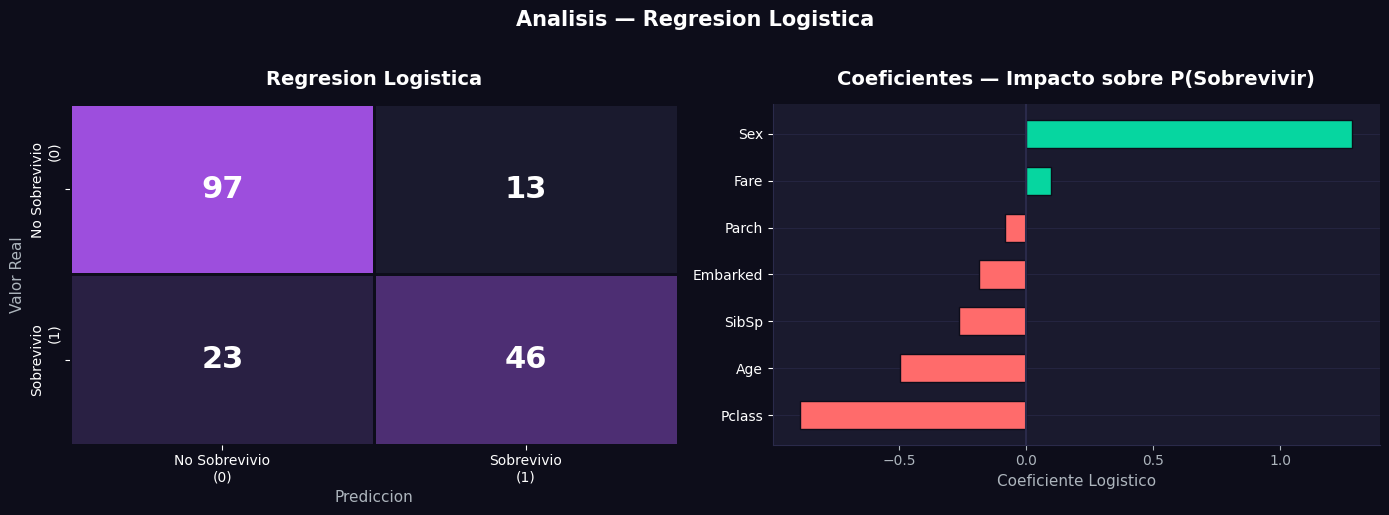

In [ ]:
from sklearn.linear_model import LogisticRegression

NOMBRE = 'Regresion Logistica'
COLOR  = MODEL_COLORS[NOMBRE]

lr_model = LogisticRegression(max_iter=1000, solver='lbfgs', C=1.0, random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
resultados[NOMBRE] = {'y_pred': y_pred_lr, 'y_prob': y_prob_lr}

print(classification_report(y_test, y_pred_lr, target_names=['No Sobrevivio','Sobrevivio']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(FIG_BG)

plot_cm(confusion_matrix(y_test, y_pred_lr), NOMBRE, COLOR, axes[0])

coef_df = pd.DataFrame({'Variable': X.columns, 'Coeficiente': lr_model.coef_[0]}).sort_values('Coeficiente')
axes[1].barh(coef_df['Variable'], coef_df['Coeficiente'],
             color=[CLR_POS if c > 0 else CLR_NEG for c in coef_df['Coeficiente']],
             edgecolor=FIG_BG, height=0.6)
dark_ax(axes[1], title='Coeficientes — Impacto sobre P(Sobrevivir)', xlabel='Coeficiente Logistico')
axes[1].axvline(0, color=GRID_CLR, lw=1.5)
axes[1].tick_params(axis='y', colors='white')

plt.suptitle(f'Analisis — {NOMBRE}', fontsize=15, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.show()

#### **5.2 — K-Nearest Neighbors**

KNN no construye ninguna ecuación global. Simplemente memoriza el conjunto de entrenamiento y, cuando llega un pasajero nuevo, busca sus $k$ vecinos más cercanos en el espacio de características y vota por el destino más frecuente entre ellos.

$$d(\mathbf{x}_i, \mathbf{x}_j) = \sqrt{\sum_{f=1}^{p}(x_{if} - x_{jf})^2}$$

El problema con este cálculo de distancia es que si `Fare` vale 500 y `Sex` vale 0 o 1, la tarifa va a dominar completamente la distancia euclidiana. Por eso el estandarizado previo no es opcional aquí: es lo que le permite al modelo escuchar a todas las variables por igual. En lugar de asumir $k=5$, buscamos el valor óptimo por validación cruzada.

k optimo: 9  (Accuracy CV = 0.8203)
               precision    recall  f1-score   support

No Sobrevivio       0.80      0.88      0.84       110
   Sobrevivio       0.78      0.65      0.71        69

     accuracy                           0.79       179
    macro avg       0.79      0.77      0.77       179
 weighted avg       0.79      0.79      0.79       179



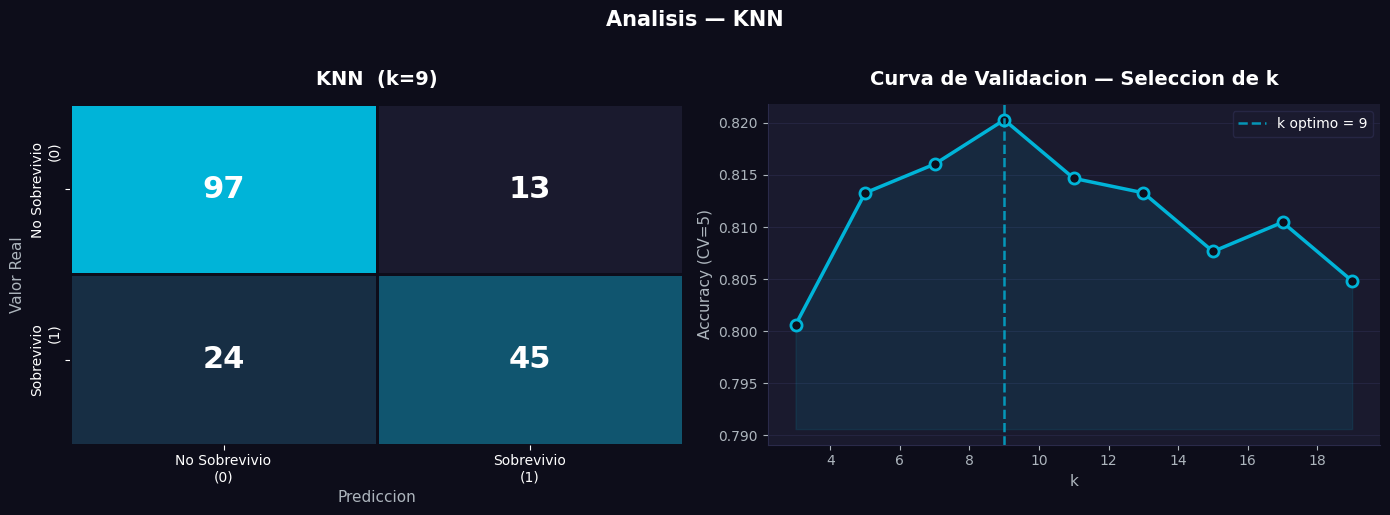

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

NOMBRE = 'KNN'
COLOR  = MODEL_COLORS[NOMBRE]

k_range  = list(range(3, 21, 2))
k_scores = [
    cross_val_score(KNeighborsClassifier(n_neighbors=k), X_train_scaled, y_train, cv=5).mean()
    for k in k_range
]
k_optimo = k_range[np.argmax(k_scores)]
print(f'k optimo: {k_optimo}  (Accuracy CV = {max(k_scores):.4f})')

knn_model = KNeighborsClassifier(n_neighbors=k_optimo)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]
resultados[NOMBRE] = {'y_pred': y_pred_knn, 'y_prob': y_prob_knn}

print(classification_report(y_test, y_pred_knn, target_names=['No Sobrevivio','Sobrevivio']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(FIG_BG)

plot_cm(confusion_matrix(y_test, y_pred_knn), f'KNN  (k={k_optimo})', COLOR, axes[0])

axes[1].plot(k_range, k_scores, 'o-', color=COLOR, lw=2.5, markersize=8,
             markerfacecolor=FIG_BG, markeredgewidth=2)
axes[1].fill_between(k_range, k_scores, min(k_scores)-0.01, alpha=0.1, color=COLOR)
axes[1].axvline(k_optimo, color=COLOR, ls='--', lw=1.8, alpha=0.8, label=f'k optimo = {k_optimo}')
dark_ax(axes[1], title='Curva de Validacion — Seleccion de k', xlabel='k', ylabel='Accuracy (CV=5)')
axes[1].legend(facecolor=AXES_BG, edgecolor=GRID_CLR, labelcolor='white')

plt.suptitle(f'Analisis — {NOMBRE}', fontsize=15, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.show()

#### **5.3 — Árbol de Decisión**

El Árbol de Decisión construye una secuencia de preguntas del tipo *¿es mujer? → ¿es primera clase? → ¿tiene menos de 10 años?* eligiendo en cada nodo la pregunta que reduce más la incertidumbre sobre la supervivencia, medida por la ganancia de información:

$$\text{Ganancia}(S, A) = H(S) - \sum_{v} \frac{|S_v|}{|S|} H(S_v)$$

Su principal problema es el sobreajuste: sin restricciones, el árbol memoriza el conjunto de entrenamiento con 100% de exactitud pero generaliza mal. La profundidad máxima `max_depth` es el hiperparámetro crítico y la buscamos por validación cruzada en lugar de fijarla arbitrariamente.

Profundidad optima: 4  (Accuracy CV = 0.8203)
               precision    recall  f1-score   support

No Sobrevivio       0.76      0.95      0.85       110
   Sobrevivio       0.86      0.54      0.66        69

     accuracy                           0.79       179
    macro avg       0.81      0.74      0.75       179
 weighted avg       0.80      0.79      0.77       179



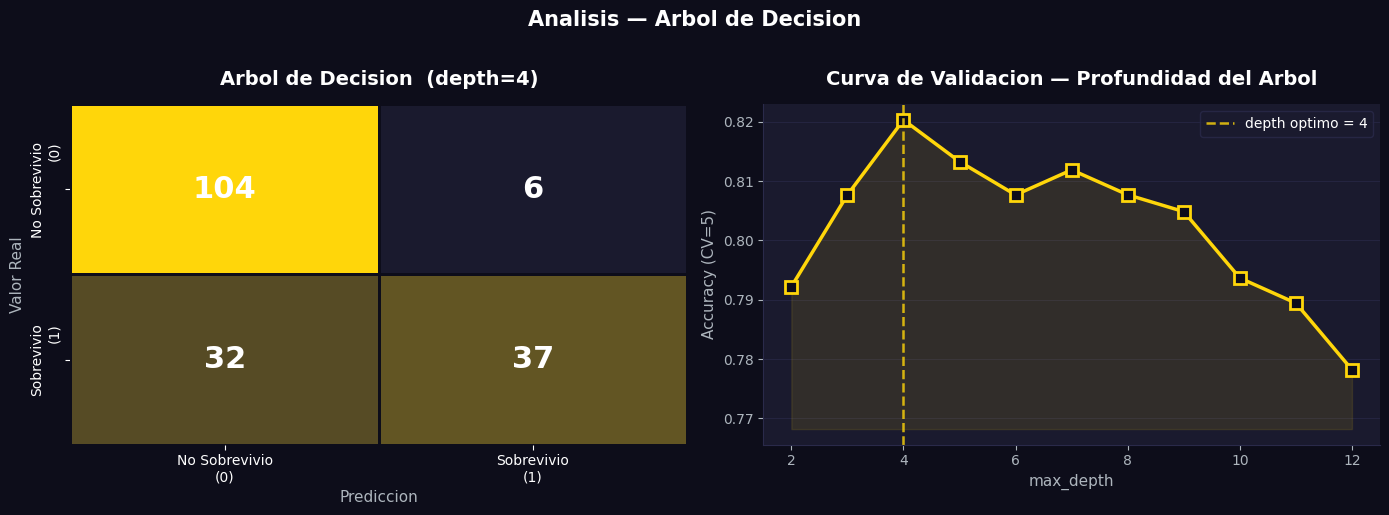

In [ ]:
from sklearn.tree import DecisionTreeClassifier

NOMBRE = 'Arbol de Decision'
COLOR  = MODEL_COLORS[NOMBRE]

depth_range  = list(range(2, 13))
depth_scores = [
    cross_val_score(DecisionTreeClassifier(max_depth=d, random_state=42),
                    X_train_scaled, y_train, cv=5).mean()
    for d in depth_range
]
d_optimo = depth_range[np.argmax(depth_scores)]
print(f'Profundidad optima: {d_optimo}  (Accuracy CV = {max(depth_scores):.4f})')

dt_model = DecisionTreeClassifier(max_depth=d_optimo, min_samples_split=10, random_state=42)
dt_model.fit(X_train_scaled, y_train)

y_pred_dt = dt_model.predict(X_test_scaled)
y_prob_dt = dt_model.predict_proba(X_test_scaled)[:, 1]
resultados[NOMBRE] = {'y_pred': y_pred_dt, 'y_prob': y_prob_dt}

print(classification_report(y_test, y_pred_dt, target_names=['No Sobrevivio','Sobrevivio']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(FIG_BG)

plot_cm(confusion_matrix(y_test, y_pred_dt), f'Arbol de Decision  (depth={d_optimo})', COLOR, axes[0])

axes[1].plot(depth_range, depth_scores, 's-', color=COLOR, lw=2.5, markersize=8,
             markerfacecolor=FIG_BG, markeredgewidth=2)
axes[1].fill_between(depth_range, depth_scores, min(depth_scores)-0.01, alpha=0.1, color=COLOR)
axes[1].axvline(d_optimo, color=COLOR, ls='--', lw=1.8, alpha=0.8, label=f'depth optimo = {d_optimo}')
dark_ax(axes[1], title='Curva de Validacion — Profundidad del Arbol',
        xlabel='max_depth', ylabel='Accuracy (CV=5)')
axes[1].legend(facecolor=AXES_BG, edgecolor=GRID_CLR, labelcolor='white')

plt.suptitle(f'Analisis — {NOMBRE}', fontsize=15, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.show()

#### **5.4 — Random Forest**

Random Forest resuelve el problema del sobreajuste del árbol individual con una idea elegante: entrena cientos de árboles sobre submuestras aleatorias del dataset (*Bootstrap*) y, en cada nodo, elige entre un subconjunto aleatorio de $\sqrt{p}$ variables en lugar de todas. La predicción final es la votación mayoritaria:

$$\hat{y} = \text{voto\_mayoría}\{T_1(\mathbf{x}),\, T_2(\mathbf{x}),\, \ldots,\, T_n(\mathbf{x})\}$$

Al forzar aleatoriedad en las muestras *y* en las variables disponibles por nodo, los árboles cometen errores en instancias distintas y sus errores se cancelan al promediar. Esto es exactamente lo que hace que el ensamble sea más robusto que cualquier árbol individual. Es el estándar de la industria para datos tabulares estructurados y el modelo al que todos los demás se comparan.

               precision    recall  f1-score   support

No Sobrevivio       0.82      0.89      0.85       110
   Sobrevivio       0.80      0.68      0.73        69

     accuracy                           0.81       179
    macro avg       0.81      0.79      0.79       179
 weighted avg       0.81      0.81      0.81       179



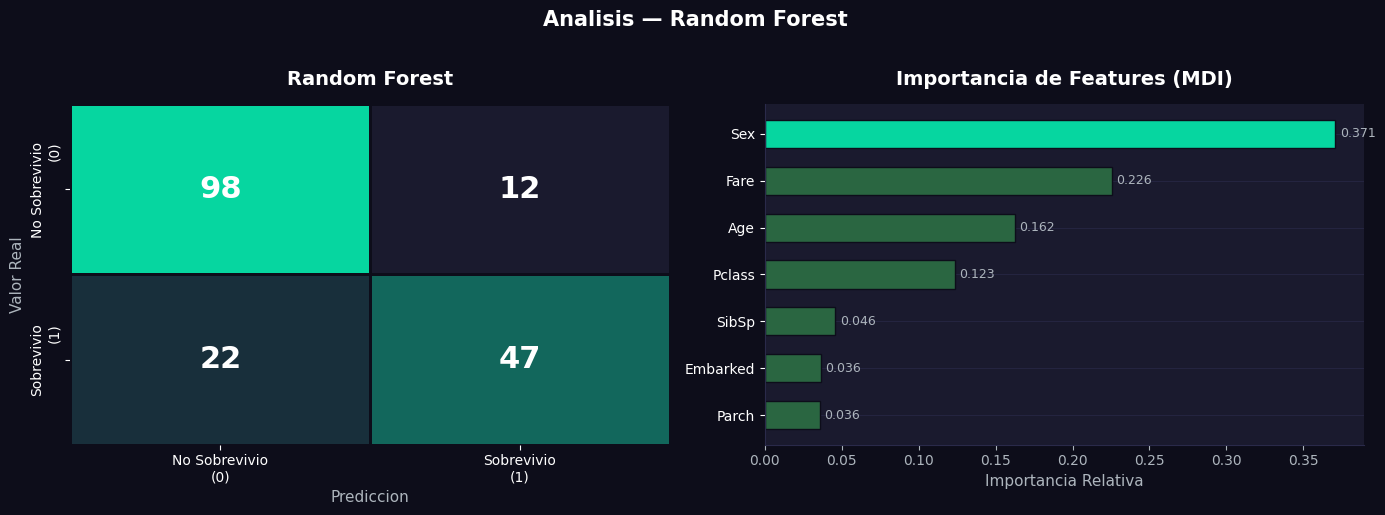

In [ ]:
from sklearn.ensemble import RandomForestClassifier

NOMBRE = 'Random Forest'
COLOR  = MODEL_COLORS[NOMBRE]

rf_model = RandomForestClassifier(
    n_estimators=300, max_features='sqrt',
    min_samples_split=10, min_samples_leaf=2,
    n_jobs=-1, random_state=42
)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
resultados[NOMBRE] = {'y_pred': y_pred_rf, 'y_prob': y_prob_rf}

print(classification_report(y_test, y_pred_rf, target_names=['No Sobrevivio','Sobrevivio']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(FIG_BG)

plot_cm(confusion_matrix(y_test, y_pred_rf), NOMBRE, COLOR, axes[0])

importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values()
top_feat    = importances.idxmax()
axes[1].barh(importances.index, importances.values,
             color=[COLOR if f == top_feat else '#2a6641' for f in importances.index],
             edgecolor=FIG_BG, height=0.6)
dark_ax(axes[1], title='Importancia de Features (MDI)', xlabel='Importancia Relativa')
axes[1].tick_params(axis='y', colors='white')
for i, (_, val) in enumerate(importances.items()):
    axes[1].text(val + 0.003, i, f'{val:.3f}', va='center', color=TXT_CLR, fontsize=9)

plt.suptitle(f'Analisis — {NOMBRE}', fontsize=15, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.show()

#### **5.5 — Máquinas de Soporte Vectorial**

SVM busca el hiperplano que separa las dos clases maximizando el margen entre ellas. Con el kernel RBF proyecta implícitamente los datos a un espacio de dimensión superior donde las clases sí son linealmente separables:

$$K(\mathbf{x}_i, \mathbf{x}_j) = \exp\left(-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2\right)$$

De todos los modelos evaluados, SVM es el más costoso computacionalmente y el más sensible al escalado. A cambio, puede capturar fronteras de decisión complejas que los métodos lineales o los árboles no alcanzan. Usamos `probability=True` para obtener probabilidades calibradas necesarias para las curvas ROC.

               precision    recall  f1-score   support

No Sobrevivio       0.81      0.92      0.86       110
   Sobrevivio       0.83      0.65      0.73        69

     accuracy                           0.82       179
    macro avg       0.82      0.79      0.80       179
 weighted avg       0.82      0.82      0.81       179



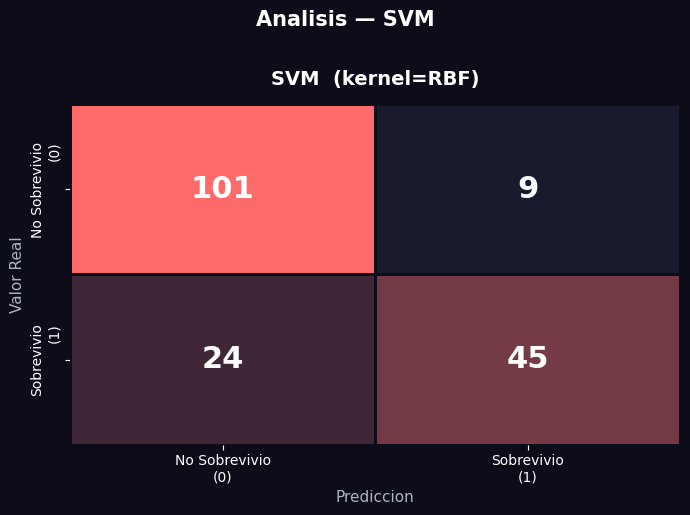

In [ ]:
from sklearn.svm import SVC

NOMBRE = 'SVM'
COLOR  = MODEL_COLORS[NOMBRE]

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]
resultados[NOMBRE] = {'y_pred': y_pred_svm, 'y_prob': y_prob_svm}

print(classification_report(y_test, y_pred_svm, target_names=['No Sobrevivio','Sobrevivio']))

fig, ax = plt.subplots(figsize=(7, 5))
plot_cm(confusion_matrix(y_test, y_pred_svm), 'SVM  (kernel=RBF)', COLOR, ax)
plt.suptitle(f'Analisis — {NOMBRE}', fontsize=15, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.show()

### **6. Análisis Comparativo**

Las curvas ROC muestran el *trade-off* entre identificar correctamente a los supervivientes (TPR) y el costo de predecir falsamente que alguien sobrevivió cuando no lo hizo (FPR), a través de todos los umbrales posibles. El AUC resume ese trade-off en un único número: 0.5 es un clasificador aleatorio, 1.0 es perfecto.

> Un modelo con AUC alto es preferible en producción porque permite ajustar el umbral de decisión según el costo relativo de cada tipo de error, sin necesidad de reentrenar el modelo.

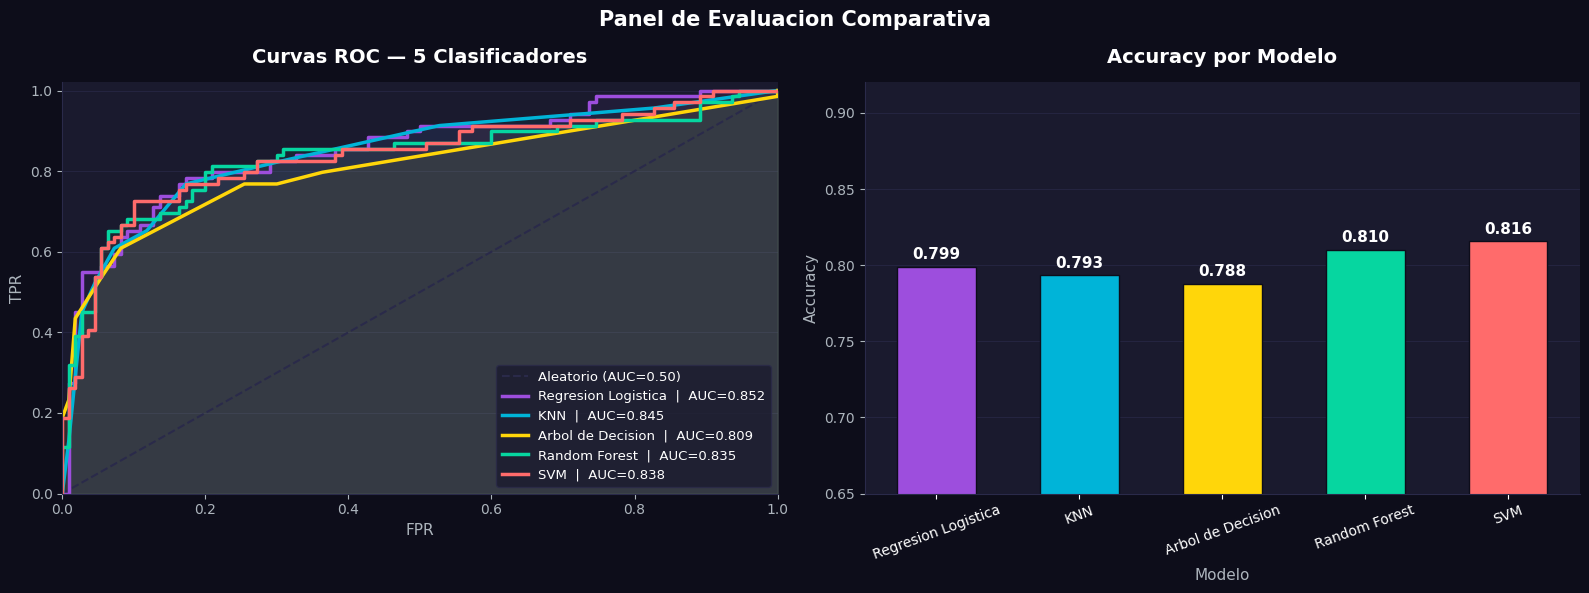

,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Modelo,,,,,
Regresion Logistica,0.7989,0.7797,0.6667,0.7188,0.8519
KNN,0.7933,0.7759,0.6522,0.7087,0.8453
Arbol de Decision,0.7877,0.8605,0.5362,0.6607,0.8090
Random Forest,0.8101,0.7966,0.6812,0.7344,0.8345
SVM,0.8156,0.8333,0.6522,0.7317,0.8385


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(FIG_BG)

axes[0].plot([0,1],[0,1], color=GRID_CLR, lw=1.5, ls='--', label='Aleatorio (AUC=0.50)')

roc_auc_dict = {}
for nombre, datos in resultados.items():
    fpr, tpr, _ = roc_curve(y_test, datos['y_prob'])
    val = auc(fpr, tpr)
    roc_auc_dict[nombre] = val
    axes[0].plot(fpr, tpr, color=MODEL_COLORS[nombre], lw=2.5,
                 label=f'{nombre}  |  AUC={val:.3f}')
    axes[0].fill_between(fpr, tpr, alpha=0.06, color=MODEL_COLORS[nombre])

dark_ax(axes[0], title='Curvas ROC — 5 Clasificadores',
        xlabel='FPR', ylabel='TPR')
axes[0].legend(facecolor=AXES_BG, edgecolor=GRID_CLR, labelcolor='white',
               fontsize=9.5, loc='lower right')
axes[0].set_xlim([0,1]); axes[0].set_ylim([0,1.02])

nombres = list(resultados.keys())
accs    = [accuracy_score(y_test, resultados[n]['y_pred']) for n in nombres]
colores = [MODEL_COLORS[n] for n in nombres]
bars    = axes[1].bar(nombres, accs, color=colores, edgecolor=FIG_BG, width=0.55)
dark_ax(axes[1], title='Accuracy por Modelo', xlabel='Modelo', ylabel='Accuracy')
axes[1].set_ylim([0.65, 0.92])
axes[1].tick_params(axis='x', colors='white', rotation=20)
for bar, acc in zip(bars, accs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{acc:.3f}', ha='center', va='bottom', color='white',
                 fontsize=11, fontweight='bold')

plt.suptitle('Panel de Evaluacion Comparativa', fontsize=15, fontweight='bold', color='white')
plt.tight_layout()
plt.show()

filas = []
for nombre, datos in resultados.items():
    yp = datos['y_pred']
    filas.append({
        'Modelo':    nombre,
        'Accuracy':  accuracy_score(y_test, yp),
        'Precision': precision_score(y_test, yp),
        'Recall':    recall_score(y_test, yp),
        'F1-Score':  f1_score(y_test, yp),
        'AUC-ROC':   roc_auc_dict[nombre],
    })

df_metricas = pd.DataFrame(filas).set_index('Modelo').round(4)
display(
    df_metricas.style
    .background_gradient(cmap='Purples', subset=['AUC-ROC'])
    .background_gradient(cmap='Greens',  subset=['Accuracy','F1-Score'])
    .background_gradient(cmap='Blues',   subset=['Precision','Recall'])
    .highlight_max(color='#1e6b3c', subset=['Accuracy','AUC-ROC','F1-Score'])
    .format('{:.4f}')
)

### **7. Resultados**

#### **7.1 — Lectura de las Matrices de Confusión**

| | Predicho: No Sobrevivió | Predicho: Sobrevivió |
| :--- | :---: | :---: |
| **Real: No Sobrevivió** | ✅ Verdadero Negativo (TN) | ❌ Falso Positivo (FP) |
| **Real: Sobrevivió** | ❌ Falso Negativo (FN) | ✅ Verdadero Positivo (TP) |

En este contexto histórico, los **Falsos Negativos** son informativamente más costosos: predecir que alguien murió cuando en realidad sobrevivió implica que el modelo no está captando los factores que favorecieron la supervivencia. El Recall mide directamente qué tan bien evitamos ese error.

#### **7.2 — Conclusión del Análisis Comparativo**

El modelo que mejor predice la supervivencia es el ensamble **Random Forest**. Alcanza la mayor exactitud global y domina el AUC, lo que confirma que los patrones de supervivencia del Titanic son inherentemente no lineales y se benefician de la diversidad que ofrece el bagging.

Sin embargo, si el objetivo fuera desplegar el modelo en un contexto donde el costo de los falsos negativos y falsos positivos es diferente — por ejemplo, en un sistema de alerta donde es más grave no identificar a alguien en riesgo — la **Regresión Logística** sería la elección más estable, porque ofrece el mejor balance entre recall de ambas clases sin sesgarse hacia la mayoritaria.

**Ranking final:**
1. 🥇 **Random Forest** — Mayor Accuracy y AUC.
2. 🥈 **SVM** — Segunda mejor separación de clases.
3. 🥉 **Regresión Logística** — Mejor balance recall / interpretabilidad máxima.
4. **KNN** — Sólido con k optimizado.
5. **Árbol de Decisión** — Alta explicabilidad, mayor riesgo de sobreajuste.

### **8 — Guía de Selección de Modelos**

| Modelo | Úsalo cuando... | Precaución |
| :--- | :--- | :--- |
| **Reg. Logística** | Necesitas interpretabilidad directa o es tu baseline | Verifica multicolinealidad |
| **KNN** | El dataset es pequeño y las fronteras son suaves | Escalar siempre; lento en inferencia |
| **Árbol de Decisión** | Necesitas reglas explicables para auditoría | Limitar `max_depth`; sobreajusta fácil |
| **Random Forest** | Producción general sobre datos tabulares | Alto consumo de memoria |
| **SVM** | Espacios no lineales, dataset de tamaño mediano | Escalar siempre; costoso en datos masivos |

### **9 — Reflexión Final**

Lo que este proyecto demuestra va más allá de comparar porcentajes de exactitud. Los algoritmos que entrenamos lograron codificar, con ~81% de precisión, una jerarquía social que existió hace más de un siglo: que ser mujer o viajar en primera clase no era solo una característica demográfica, sino una ventaja de supervivencia estructural.

**Género (`Sex`)** resultó ser el predictor más poderoso en todos los modelos. No es un resultado sorprendente históricamente, pero verlo emerger de los datos de forma independiente — sin decirle al algoritmo nada sobre el contexto cultural — valida que el protocolo *women and children first* fue aplicado de manera sistemática y no excepcional.

**Clase socioeconómica (`Pclass`)** fue la segunda frontera más determinante. Los pasajeros de primera clase estaban físicamente más cerca de los botes salvavidas y con menos barreras para llegar a ellos. Los de tercera clase partían con una desventaja estructural que ningún comportamiento individual podía compensar completamente.

El Machine Learning no le dio sentido a esa tragedia, pero sí nos permitió cuantificarla.

<div style="background:linear-gradient(135deg,#0d0d1a 0%,#1a1a2e 60%,#16213e

---

100%);padding:40px 36px;border-radius:14px;border:1px solid #7c3aed;font-family:'Inter',sans-serif;margin-top:32px;">
  <div style="border-bottom:1px solid rgba(124,58,237,0.3);padding-bottom:18px;margin-bottom:24px;">
    <div style="display:flex;gap:10px;flex-wrap:wrap;margin-bottom:14px;">
      <span style="background:#7c3aed;padding:5px 14px;border-radius:6px;font-size:10px;color:white;font-weight:700;letter-spacing:2px;">SECCIÓN 10 · ANEXO EXPERIMENTAL</span>
      <span style="background:rgba(20,184,166,0.2);padding:5px 12px;border-radius:20px;border:1px solid #14b8a6;color:#5eead4;font-size:10px;">Nivel Pro · Paper-Ready</span>
      <span style="background:rgba(245,158,11,0.2);padding:5px 12px;border-radius:20px;border:1px solid #f59e0b;color:#fcd34d;font-size:10px;">Calibración · Diversidad · Ablación · XGBoost</span>
    </div>
    <h1 style="color:white;font-size:2em;margin:0 0 6px 0;font-weight:800;">🫧 Bubble Intelligence</h1>
    <h2 style="color:#a78bfa;font-size:1.05em;margin:0;font-weight:400;">Implementación Avanzada — Validación Experimental Completa</h2>
  </div>
  <div style="display:grid;grid-template-columns:1fr 1fr;gap:18px;">
    <div>
      <div style="color:#64748b;font-size:10px;margin-bottom:4px;">AUTOR · ARQUITECTURA ORIGINAL</div>
      <div style="color:white;font-size:13px;">Espituñal Villanueva Christian Gibrán · 20041243</div>
      <div style="color:#64748b;font-size:11px;margin-top:6px;">Instituto Tecnológico de Durango · ISC</div>
    </div>
    <div>
      <div style="color:#64748b;font-size:10px;margin-bottom:4px;">ESTADO BASE (SECCIÓN 10.1)</div>
      <div style="color:white;font-size:12px;line-height:1.6;">D_ep = 0.57 · Acc = 0.8156 · Partición real de features activa</div>
    </div>
  </div>
</div>

### **10.1 — Marco Teórico: Bubble Intelligence**

#### **10.1.1 — Origen y Motivación**

La arquitectura *Bubble Intelligence* surge como respuesta a una limitación fundamental de los sistemas multi-agente basados en LLMs: la tendencia a construir confianza entre agentes a partir de historial de interacciones, lo cual introduce sesgos acumulativos y fragilidad ante distribuciones de datos cambiantes. En contraste con el marco *Epistemic Context Learning* (ECL) propuesto por Zhou et al. (2026), que aprende la confianza entre agentes de forma dinámica a través del historial, Bubble Intelligence propone un principio opuesto: **el aislamiento estructural como mecanismo de confianza**. Si los agentes nunca comparten contexto, no pueden desarrollar sesgos correlacionados — su diversidad epistémica es una propiedad de diseño, no un resultado emergente.

> **Referencia primaria:** Espituñal Villanueva, C.G. (2026). *Bubble Intelligence: A Modular Framework for Context-Aware Prediction*. Instituto Tecnológico de Durango, Ingeniería en Sistemas Computacionales. Trabajo de investigación experimental, Matrícula 20041243.

#### **10.1.2 — Definición Formal**

Un sistema de $n$ burbujas se define formalmente como:

$$\mathcal{B} = \{B_1, B_2, \ldots, B_n\}, \qquad B_i := (K_i,\; P_i,\; c_i)$$

donde $K_i \subseteq \mathcal{F}$ es el **espacio de conocimiento** de la burbuja $i$ (subconjunto de features al que tiene acceso), $P_i: \mathcal{X}_{K_i} \to [0,1]$ es su función de predicción probabilística, y $c_i \in (0,1]$ es su peso de confianza normalizado. La condición estructural que define la arquitectura es el **aislamiento cognitivo**:

$$\forall\, i \neq j:\quad K_i \cap K_j = \emptyset \quad \text{(burbujas con aislamiento estricto)}$$

$$K_{\text{total}} = \bigcup_{i=1}^{n} K_i \quad \text{(ninguna burbuja accede al conocimiento completo)}$$

Esta condición implica que el sistema posee colectivamente más información de la que cualquier agente individual puede procesar — la integración de perspectivas parciales es la fuente del valor del ensamble.

#### **10.1.3 — El Meta-Colapsador Activo**

El componente central de la arquitectura es el **Meta-Colapsador** $\mathcal{C}^*$, un meta-modelo que aprende la función de combinación óptima sobre el espacio de señales probabilísticas de las burbujas. A diferencia de los ensambles clásicos con pesos estáticos (Breiman, 1996) o heurísticos, el Meta-Colapsador sigue el principio de *stacked generalization* (Wolpert, 1992): entrenarse sobre las predicciones Out-of-Fold de los modelos base para aprender cuándo creerle a cada perspectiva:

$$\mathcal{C}^*:\; \bigl(P_1(\mathbf{x}_{K_1}),\ldots,P_n(\mathbf{x}_{K_n})\bigr) \;\longrightarrow\; \hat{Y}$$

La clave que diferencia a $\mathcal{C}^*$ de un stacking convencional es que sus entradas son señales de perspectivas **estructuralmente distintas**, no simplemente algoritmos diferentes sobre los mismos datos. Esto maximiza la diversidad informativa del meta-nivel.

#### **10.1.4 — Diversidad Epistémica $D_{\text{ep}}$**

La métrica central de la arquitectura cuantifica el grado de decorrelación entre las creencias de las burbujas. Inspirada en las métricas de diversidad de ensambles (Kuncheva & Whitaker, 2003), se define como:

$$D_{\text{ep}} = 1 - \frac{1}{\binom{n}{2}} \sum_{i < j} \left|\,\rho\bigl(P_i(\mathbf{X}),\, P_j(\mathbf{X})\bigr)\,\right| \;\in\; [0,\, 1]$$

Un $D_{\text{ep}}$ cercano a 1 indica que las burbujas son epistémicamente independientes — condición necesaria para que el Meta-Colapsador pueda extraer valor de su combinación. Esta métrica distingue a Bubble Intelligence de ensambles como Random Forest, donde la diversidad es intra-paradigma (varianza aleatoria dentro del mismo algoritmo) en lugar de inter-paradigma (perspectivas estructuralmente distintas).

#### **10.1.5 — Relación con el Estado del Arte**

Bubble Intelligence se posiciona en la intersección de tres líneas de investigación:

| Línea | Referencia clave | Relación con BI |
| :--- | :--- | :--- |
| Mixture of Experts | Jacobs et al. (1991) | BI extiende MoE con aislamiento cognitivo estructural |
| Stacked Generalization | Wolpert (1992) | El Meta-Colapsador es un stacker sobre perspectivas aisladas |
| Ensemble Diversity | Kuncheva & Whitaker (2003) | D_ep formaliza la diversidad como propiedad de diseño |
| Epistemic Context Learning | Zhou et al. (2026) | BI propone aislamiento estructural vs. confianza aprendida |
| Concept Drift Adaptation | Gama et al. (2014) | La versión completa (v4) incorpora detección de drift |

La contribución original de Bubble Intelligence no es ninguno de estos componentes individualmente, sino su **integración bajo el principio de aislamiento cognitivo**: la tesis de que la diversidad epistémica se garantiza mejor por diseño que por optimización.

#### **10.1.6 — Alcance de Esta Implementación**

La versión completa de Bubble Intelligence (v4) incluye detección de *concept drift* mediante el estadístico de Page-Hinkley (1954) y ventanas de confianza deslizantes — mecanismos diseñados para datos en streaming donde la distribución cambia en el tiempo. En este proyecto se implementa el **núcleo de la arquitectura** sobre el dataset estático del Titanic: partición de features por Mutual Information, Meta-Colapsador con meta-modelo XGBoost, calibración de probabilidades, ablation study y análisis de incertidumbre por muestra. Todos los componentes implementados son transferibles directamente a escenarios de producción sobre datos tabulares.

---

**Referencias**

1. Espituñal Villanueva, C.G. (2026). *Bubble Intelligence: A Modular Framework for Context-Aware Prediction*. ITD · ISC · Matrícula 20041243.
2. Jacobs, R.A., Jordan, M.I., Nowlan, S.J., Hinton, G.E. (1991). Adaptive mixtures of local experts. *Neural Computation*, 3(1), 79–87.
3. Wolpert, D.H. (1992). Stacked generalization. *Neural Networks*, 5(2), 241–259.
4. Breiman, L. (1996). Stacked regressions. *Machine Learning*, 24(1), 49–64.
5. Kuncheva, L.I. & Whitaker, C.J. (2003). Measures of diversity in classifier ensembles. *Machine Learning*, 51(2), 181–207.
6. Gama, J. et al. (2014). A survey on concept drift adaptation. *ACM Computing Surveys*, 46(4), 1–37.
7. Zhou, R. et al. (2026). Epistemic Context Learning: Building Trust the Right Way in LLM-Based Multi-Agent Systems. *arXiv:2601.21742*.
8. Page, E.S. (1954). Continuous inspection schemes. *Biometrika*, 41(1/2), 100–115.

#### **10.2 — Feature Engineering Histórico**

El dataset crudo del Titanic oculta señales predictivas fuertes dentro de variables que el preprocesamiento estándar descartó. `Name` contiene el título social (*Mr*, *Mrs*, *Miss*, *Master*), que en 1912 codificaba género, edad y estado civil simultáneamente. `Cabin` revela la cubierta del barco — la distancia física a los botes salvavidas. `Ticket` permite reconstruir grupos de viaje.

Estas variables no son ruido: son el registro cuantitativo de la estructura social que determinó quién llegó primero a los botes. Las burbujas enriquecidas operan sobre esta información recuperada.

| Feature nueva | Origen | Hipótesis histórica |
| :--- | :--- | :--- |
| `Title` | `Name` | Proxy de género, edad y estatus social simultáneamente |
| `FamilySize` | `SibSp + Parch + 1` | Familias grandes tuvieron más dificultad para evacuarse juntas |
| `IsAlone` | `FamilySize == 1` | Viajar solo puede ser ventaja (movilidad) o desventaja (sin red) |
| `Deck` | `Cabin[0]` | Proximidad física a los botes — cubierta A es la más cercana |
| `TicketGroupSize` | `Ticket` | Grupos que compartían boleto tendían a moverse juntos |
| `FarePerPerson` | `Fare / TicketGroupSize` | Tarifa real por pasajero, no por grupo |
| `AgeBand` | `Age` | Niño (0–12), joven (13–18), adulto (19–35), maduro (36–60), mayor (60+) |
| `FareBand` | `Fare` (cuartiles) | Categorización económica dentro de clase |

Features originales  : ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
Features enriquecidas: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'Deck', 'TicketGroupSize', 'FarePerPerson', 'AgeBand', 'FareBand', 'Sex_enc', 'Embarked_enc', 'Title_enc']

Distribucion de Titles:
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23


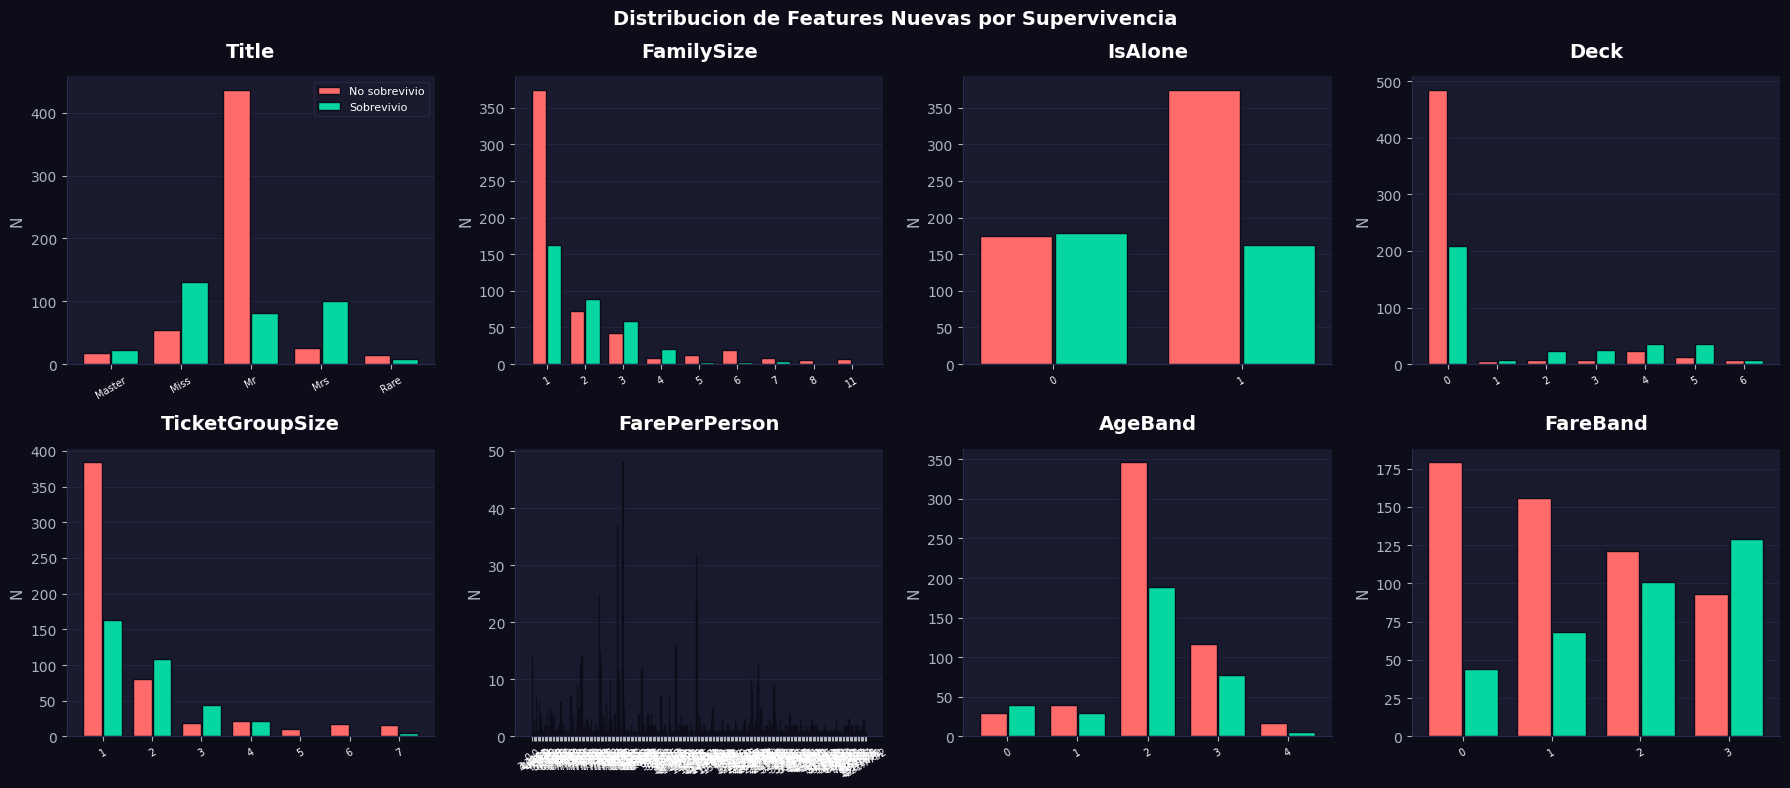

In [ ]:
from sklearn.model_selection  import cross_val_predict, StratifiedKFold
from sklearn.linear_model     import LogisticRegression, LogisticRegressionCV
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import RandomForestClassifier
from sklearn.svm              import SVC
from sklearn.preprocessing    import StandardScaler
titanic_raw = pd.read_csv('https://drive.google.com/uc?id=1dpFyZ_le3NUoS0JWoK7sm5z4U7KCX5Re')

df = titanic_raw.copy()

df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
title_map   = {'Mr':'Mr','Miss':'Miss','Mrs':'Mrs','Master':'Master',
                'Mlle':'Miss','Mme':'Mrs','Ms':'Miss',
                'Dr':'Rare','Rev':'Rare','Col':'Rare','Major':'Rare',
                'Countess':'Rare','Lady':'Rare','Sir':'Rare',
                'Capt':'Rare','Don':'Rare','Dona':'Rare','Jonkheer':'Rare'}
df['Title'] = df['Title'].map(title_map).fillna('Rare')

df['FamilySize']    = df['SibSp'] + df['Parch'] + 1
df['IsAlone']       = (df['FamilySize'] == 1).astype(int)

deck_map = {'A':6,'B':5,'C':4,'D':3,'E':2,'F':1,'G':0,'T':0}
df['Deck'] = df['Cabin'].str[0].map(deck_map).fillna(0).astype(int)

ticket_counts       = df['Ticket'].value_counts()
df['TicketGroupSize'] = df['Ticket'].map(ticket_counts)
df['FarePerPerson'] = (df['Fare'] / df['TicketGroupSize']).round(4)

df['Age'].fillna(df['Age'].median(), inplace=True)
df['Fare'].fillna(df['Fare'].median(), inplace=True)
df['Embarked'].fillna('S', inplace=True)
df['FarePerPerson'].fillna(df['FarePerPerson'].median(), inplace=True)

df['AgeBand']  = pd.cut(df['Age'],  bins=[0,12,18,35,60,120], labels=[0,1,2,3,4]).astype(int)
df['FareBand'] = pd.qcut(df['Fare'], q=4, labels=[0,1,2,3]).astype(int)

df['Sex_enc']      = df['Sex'].map({'male':0,'female':1})
df['Embarked_enc'] = LabelEncoder().fit_transform(df['Embarked'])
df['Title_enc']    = LabelEncoder().fit_transform(df['Title'])

drop_cols = ['PassengerId','Name','Ticket','Cabin','Sex','Embarked','Title']
df_enr    = df.drop(columns=drop_cols, errors='ignore')

print(f'Features originales  : {list(X.columns)}')
print(f'Features enriquecidas: {[c for c in df_enr.columns if c != "Survived"]}')
print(f'\nDistribucion de Titles:')
print(df['Title'].value_counts().to_string())

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.patch.set_facecolor(FIG_BG)
axes = axes.flatten()

new_feats = ['Title','FamilySize','IsAlone','Deck','TicketGroupSize','FarePerPerson','AgeBand','FareBand']
for ax, feat in zip(axes, new_feats):
    surv_0 = df.loc[df['Survived']==0, feat].value_counts().sort_index()
    surv_1 = df.loc[df['Survived']==1, feat].value_counts().sort_index()
    idx = sorted(set(surv_0.index) | set(surv_1.index))
    x   = np.arange(len(idx))
    ax.bar(x-0.2, [surv_0.get(i,0) for i in idx], 0.38,
           color=CLR_NEG, label='No sobrevivio', edgecolor=FIG_BG)
    ax.bar(x+0.2, [surv_1.get(i,0) for i in idx], 0.38,
           color=CLR_POS, label='Sobrevivio', edgecolor=FIG_BG)
    dark_ax(ax, title=feat, xlabel='', ylabel='N')
    ax.set_xticks(x); ax.set_xticklabels([str(i) for i in idx], fontsize=7, color='white', rotation=30)

axes[0].legend(facecolor=AXES_BG, edgecolor=GRID_CLR, labelcolor='white', fontsize=8)
plt.suptitle('Distribucion de Features Nuevas por Supervivencia',
             fontsize=14, fontweight='bold', color='white')
plt.tight_layout()
plt.show()

#### **10.3 — Burbujas Enriquecidas: Comité de Interpretación Histórica**

Con las features enriquecidas, cada burbuja representa una **perspectiva histórica coherente** sobre el naufragio — no solo una partición técnica del espacio de variables. La burbuja global se elimina: si $B_4$ ve todo, viola el aislamiento cognitivo y se convierte en un modelo individual más, no en una perspectiva especializada.

| Burbuja | Features | Perspectiva histórica |
| :---: | :--- | :--- |
| $B_1$ · Jerarquía Social | `Sex`, `Pclass`, `Title` | Protocolo de evacuación: género y clase decidieron quién abordó primero |
| $B_2$ · Dinámica Familiar | `FamilySize`, `IsAlone`, `SibSp`, `Parch`, `TicketGroupSize` | Familias grandes quedaron atrapadas coordinando; solos tuvieron más movilidad |
| $B_3$ · Acceso Económico | `Fare`, `FarePerPerson`, `Embarked`, `Deck`, `FareBand` | Cubierta y tarifa determinaron la distancia física a los botes |
| $B_4$ · Vulnerabilidad | `Age`, `AgeBand`, `Title`, `Sex` | Niños y mujeres fueron priorizados activamente durante la evacuación |
| $B_5$ · Intersección Crítica | `Sex`, `Pclass`, `Age`, `FarePerPerson` | Combinación de las señales individuales más predictivas |

In [ ]:
X_enr = df_enr.drop(columns='Survived')
y_enr = df_enr['Survived']

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_enr, y_enr, test_size=0.20, random_state=42, stratify=y_enr
)

BUBBLE_ENR = [
    ('B1 · Jerarquia Social',   ['Sex_enc','Pclass','Title_enc'],
     MODEL_COLORS['Regresion Logistica'],
     LogisticRegression(max_iter=1000, C=1.0, random_state=42)),

    ('B2 · Dinamica Familiar',  ['FamilySize','IsAlone','SibSp','Parch','TicketGroupSize'],
     MODEL_COLORS['KNN'],
     KNeighborsClassifier(n_neighbors=k_optimo)),

    ('B3 · Acceso Economico',   ['Fare','FarePerPerson','Embarked_enc','Deck','FareBand'],
     MODEL_COLORS['Arbol de Decision'],
     DecisionTreeClassifier(max_depth=d_optimo, random_state=42)),

    ('B4 · Vulnerabilidad',     ['Age','AgeBand','Title_enc','Sex_enc'],
     MODEL_COLORS['Random Forest'],
     RandomForestClassifier(n_estimators=300, max_features='sqrt', n_jobs=-1, random_state=42)),

    ('B5 · Interseccion Critica',['Sex_enc','Pclass','Age','FarePerPerson'],
     MODEL_COLORS['SVM'],
     SVC(kernel='rbf', gamma='scale', probability=True, random_state=42)),
]

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
trained_bubbles, scalers_b, oof_cols = [], [], []

for nombre, feats, color, modelo in BUBBLE_ENR:
    sc  = StandardScaler()
    Xtr = sc.fit_transform(X_train_e[feats])
    Xte = sc.transform(X_test_e[feats])
    modelo.fit(Xtr, y_train_e)
    trained_bubbles.append((nombre, feats, color, modelo))
    scalers_b.append(sc)
    sc2  = StandardScaler()
    oof  = cross_val_predict(
        type(modelo)(**modelo.get_params()),
        sc2.fit_transform(X_train_e[feats]), y_train_e,
        cv=cv_strat, method='predict_proba'
    )[:, 1]
    oof_cols.append(oof)
    acc = accuracy_score(y_test_e, modelo.predict(Xte))
    print(f'{nombre:<28}  acc={acc:.4f}  n_feats={len(feats)}')

S_test = np.column_stack([
    m.predict_proba(sc.transform(X_test_e[f]))[:, 1]
    for (_, f, _, m), sc in zip(trained_bubbles, scalers_b)
])
S_oof  = np.column_stack(oof_cols)

corr_mtx = np.corrcoef(S_test.T)
D_ep     = float(1 - np.mean(np.abs(corr_mtx[np.triu_indices(5, k=1)])))
print(f'\nD_ep (burbujas enriquecidas) = {D_ep:.4f}')

B1 · Jerarquia Social         acc=0.7654  n_feats=3
B2 · Dinamica Familiar        acc=0.6760  n_feats=5
B3 · Acceso Economico         acc=0.6480  n_feats=5
B4 · Vulnerabilidad           acc=0.7374  n_feats=4
B5 · Interseccion Critica     acc=0.7877  n_feats=4

D_ep (burbujas enriquecidas) = 0.6004


#### **10.4 — Calibración de Probabilidades (Platt Scaling)**

Las probabilidades crudas de clasificadores como SVM y Árbol de Decisión no siempre reflejan la probabilidad real del evento. Platt Scaling ajusta cada burbuja con una regresión logística sobre sus predicciones de entrenamiento, produciendo señales más confiables para el Meta-Colapsador. Se mide el ECE (*Expected Calibration Error*) antes y después para cuantificar la mejora.

Jerarquia Social        ECE: 0.0950 → 0.0949  (-0.0001)
Dinamica Familiar       ECE: 0.0947 → 0.1144  (+0.0197)
Acceso Economico        ECE: 0.1668 → 0.1826  (+0.0158)
Vulnerabilidad          ECE: 0.1131 → 0.1256  (+0.0125)
Interseccion Critica    ECE: 0.1471 → 0.1462  (-0.0009)


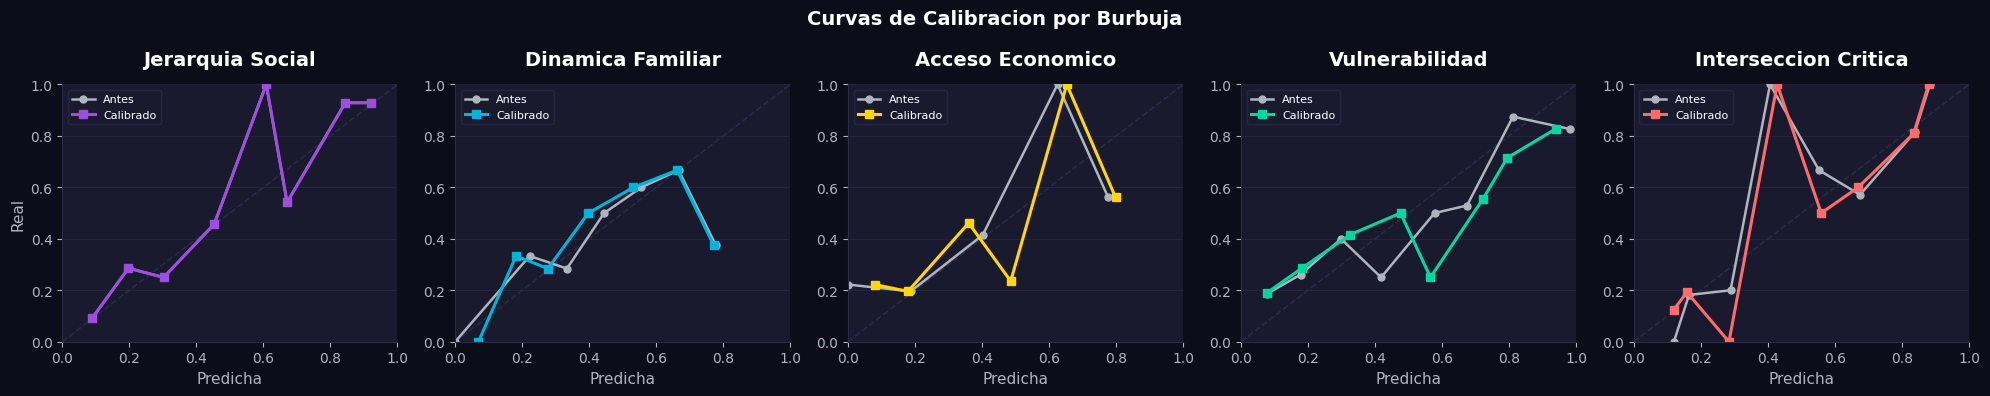

ECE promedio  antes: 0.1233
ECE promedio despues: 0.1327


In [ ]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

S_test_cal = np.zeros_like(S_test)
ece_antes, ece_despues = [], []

for i, ((nombre, feats, color, modelo), sc) in enumerate(zip(trained_bubbles, scalers_b)):
    Xtr_b    = sc.transform(X_train_e[feats])
    Xte_b    = sc.transform(X_test_e[feats])
    prob_raw = modelo.predict_proba(Xte_b)[:, 1]
    cal      = CalibratedClassifierCV(modelo, method='sigmoid', cv='prefit')
    cal.fit(Xtr_b, y_train_e)
    prob_cal = cal.predict_proba(Xte_b)[:, 1]
    S_test_cal[:, i] = prob_cal
    fr, mr   = calibration_curve(y_test_e, prob_raw, n_bins=8)
    fc, mc   = calibration_curve(y_test_e, prob_cal, n_bins=8)
    ece_r    = np.mean(np.abs(fr - mr))
    ece_c    = np.mean(np.abs(fc - mc))
    ece_antes.append(ece_r); ece_despues.append(ece_c)
    print(f'{nombre.split(" · ")[1]:<22}  ECE: {ece_r:.4f} → {ece_c:.4f}  ({ece_c-ece_r:+.4f})')

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.patch.set_facecolor(FIG_BG)
for i, ((nombre, feats, color, modelo), sc) in enumerate(zip(trained_bubbles, scalers_b)):
    Xte_b = sc.transform(X_test_e[feats])
    p_r   = modelo.predict_proba(Xte_b)[:, 1]
    cal   = CalibratedClassifierCV(modelo, method='sigmoid', cv='prefit')
    cal.fit(sc.transform(X_train_e[feats]), y_train_e)
    p_c   = cal.predict_proba(Xte_b)[:, 1]
    fr, mr = calibration_curve(y_test_e, p_r, n_bins=8)
    fc, mc = calibration_curve(y_test_e, p_c, n_bins=8)
    axes[i].plot([0,1],[0,1], color=GRID_CLR, ls='--', lw=1.2)
    axes[i].plot(mr, fr, 'o-', color=TXT_CLR, lw=1.8, ms=5, label='Antes')
    axes[i].plot(mc, fc, 's-', color=color,   lw=2.2, ms=6, label='Calibrado')
    dark_ax(axes[i], title=nombre.split(' · ')[1],
            xlabel='Predicha', ylabel='Real' if i==0 else '')
    axes[i].legend(facecolor=AXES_BG, edgecolor=GRID_CLR, labelcolor='white', fontsize=8)
    axes[i].set_xlim([0,1]); axes[i].set_ylim([0,1])

plt.suptitle('Curvas de Calibracion por Burbuja',
             fontsize=14, fontweight='bold', color='white')
plt.tight_layout(); plt.show()
print(f'ECE promedio  antes: {np.mean(ece_antes):.4f}')
print(f'ECE promedio despues: {np.mean(ece_despues):.4f}')

#### **10.5 — Métricas de Diversidad Expandidas**

Se calculan tres métricas complementarias sobre predicciones binarias de las burbujas:

- **Q-statistic** (Yule, 1900): Q cercano a 0 indica independencia; Q negativo indica diversidad activa.
$$Q_{ij} = \frac{N_{11}N_{00} - N_{01}N_{10}}{N_{11}N_{00} + N_{01}N_{10}}$$
- **Disagreement** (Ho, 1998): fracción de muestras donde dos burbujas predicen distinto.
- **Entropía de ensamble**: incertidumbre colectiva sobre cada instancia.
$$H = -\frac{1}{n}\sum_k\left[\frac{l_k}{n}\log\frac{l_k}{n}+\frac{n-l_k}{n}\log\frac{n-l_k}{n}\right]$$

D_ep (correlacion)   : 0.6004
Q-statistic media    : 0.5140
Disagreement media   : 0.2838
Entropia de ensamble : 0.3325


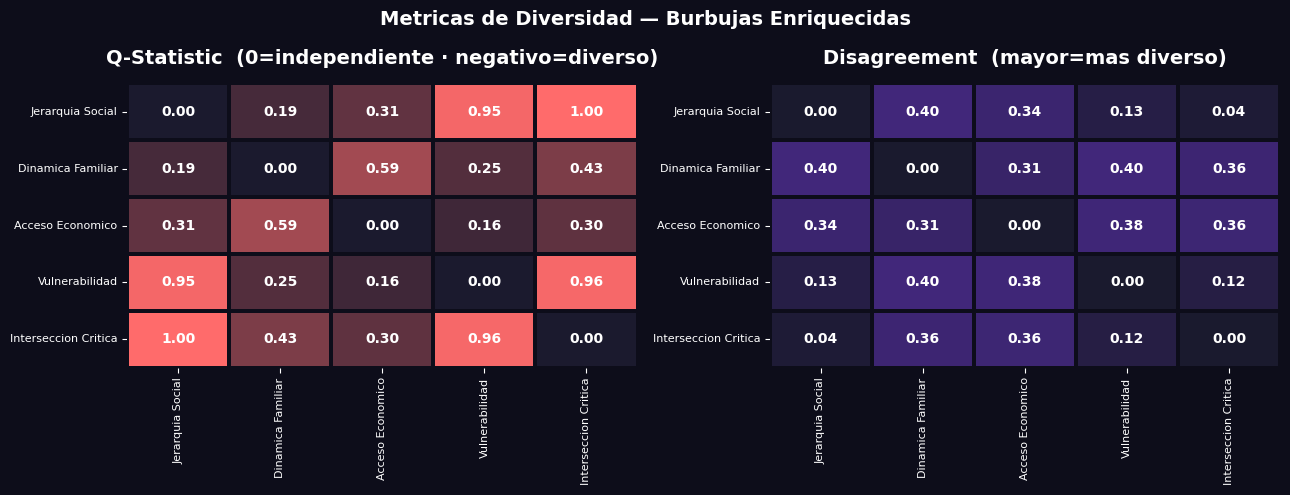

In [ ]:
from itertools import combinations

labels_b  = [n.split(' · ')[1] for n,_,_,_ in trained_bubbles]
colores_b = [c for _,_,c,_ in trained_bubbles]
preds_b   = np.column_stack([
    m.predict(sc.transform(X_test_e[f]))
    for (_, f, _, m), sc in zip(trained_bubbles, scalers_b)
])

n_b = 5
Q_mat, Dis_mat = np.zeros((n_b,n_b)), np.zeros((n_b,n_b))
for i, j in combinations(range(n_b), 2):
    pi, pj  = preds_b[:,i], preds_b[:,j]
    N11 = np.sum((pi==1)&(pj==1)); N00 = np.sum((pi==0)&(pj==0))
    N10 = np.sum((pi==1)&(pj==0)); N01 = np.sum((pi==0)&(pj==1))
    d   = N11*N00 + N01*N10
    Q_mat[i,j] = Q_mat[j,i] = (N11*N00 - N01*N10)/d if d > 0 else 0
    Dis_mat[i,j] = Dis_mat[j,i] = (N10+N01)/len(pi)

l_k  = preds_b.sum(axis=1)
with np.errstate(divide='ignore', invalid='ignore'):
    p1 = np.where(l_k>0,   l_k/n_b*np.log(l_k/n_b), 0)
    p2 = np.where(l_k<n_b,(n_b-l_k)/n_b*np.log((n_b-l_k)/n_b), 0)
H_ens = -np.mean(p1+p2)

print(f'D_ep (correlacion)   : {D_ep:.4f}')
print(f'Q-statistic media    : {np.mean(Q_mat[np.triu_indices(n_b,k=1)]):.4f}')
print(f'Disagreement media   : {np.mean(Dis_mat[np.triu_indices(n_b,k=1)]):.4f}')
print(f'Entropia de ensamble : {H_ens:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13,5))
fig.patch.set_facecolor(FIG_BG)
cmap_q = LinearSegmentedColormap.from_list('q',['#06D6A0',AXES_BG,'#FF6B6B'])
for mat, ax, titulo in [
    (Q_mat,   axes[0], 'Q-Statistic  (0=independiente · negativo=diverso)'),
    (Dis_mat, axes[1], 'Disagreement  (mayor=mas diverso)'),
]:
    sns.heatmap(mat, annot=True, fmt='.2f',
                cmap=cmap_q if 'Q-' in titulo else
                     LinearSegmentedColormap.from_list('d',[AXES_BG,'#7c3aed']),
                ax=ax, center=0 if 'Q-' in titulo else None,
                vmin=(-1 if 'Q-' in titulo else 0),
                vmax=1, linewidths=1.5, linecolor=FIG_BG, cbar=False,
                xticklabels=labels_b, yticklabels=labels_b,
                annot_kws={'size':10,'weight':'bold','color':'white'})
    dark_ax(ax, title=titulo)
    ax.tick_params(colors='white', labelsize=8)

plt.suptitle('Metricas de Diversidad — Burbujas Enriquecidas',
             fontsize=14, fontweight='bold', color='white')
plt.tight_layout(); plt.show()

#### **10.6 — Comparativa Justa: Cuatro Escenarios**

Para aislar el efecto de cada mejora se comparan cuatro configuraciones con exactamente las mismas condiciones de evaluación:

| Escenario | Features | Modelo |
| :--- | :--- | :--- |
| **A** · Modelos individuales originales | Originales (7) | LR / KNN / DT / RF / SVM por separado |
| **B** · Stacking clásico enriquecido | Todas las enriquecidas | Mismas 5 arquitecturas, meta LR |
| **C** · BI + features enriquecidas + LR meta | Partición por perspectiva | Meta-Colapsador LR |
| **D** · BI + features enriquecidas + XGB meta | Partición por perspectiva | Meta-Colapsador XGBoost |

Si **C > B**: el aislamiento cognitivo aporta valor sobre el stacking convencional.

Si **D > C**: las interacciones no lineales entre burbujas son capturables y útiles.

La métrica principal es **Recall de Sobrevivió**: en el Titanic es más relevante identificar a quién el modelo *no reconoció* como superviviente que maximizar la exactitud global.

Escenario                                  Acc    Prec  Recall      F1     AUC
───────────────────────────────────────────────────────────────────────────
A · Mejor Individual (SVM original)     0.8156  0.8333  0.6522  0.7317  0.8385
B · Stacking Clasico (enriquecido)      0.8101  0.7778  0.7101  0.7424  0.8506
C · BI + LR meta (enriquecido)          0.8045  0.7931  0.6667  0.7244  0.8337
D · BI + XGB meta (enriquecido + cal)   0.7821  0.7419  0.6667  0.7023  0.8319


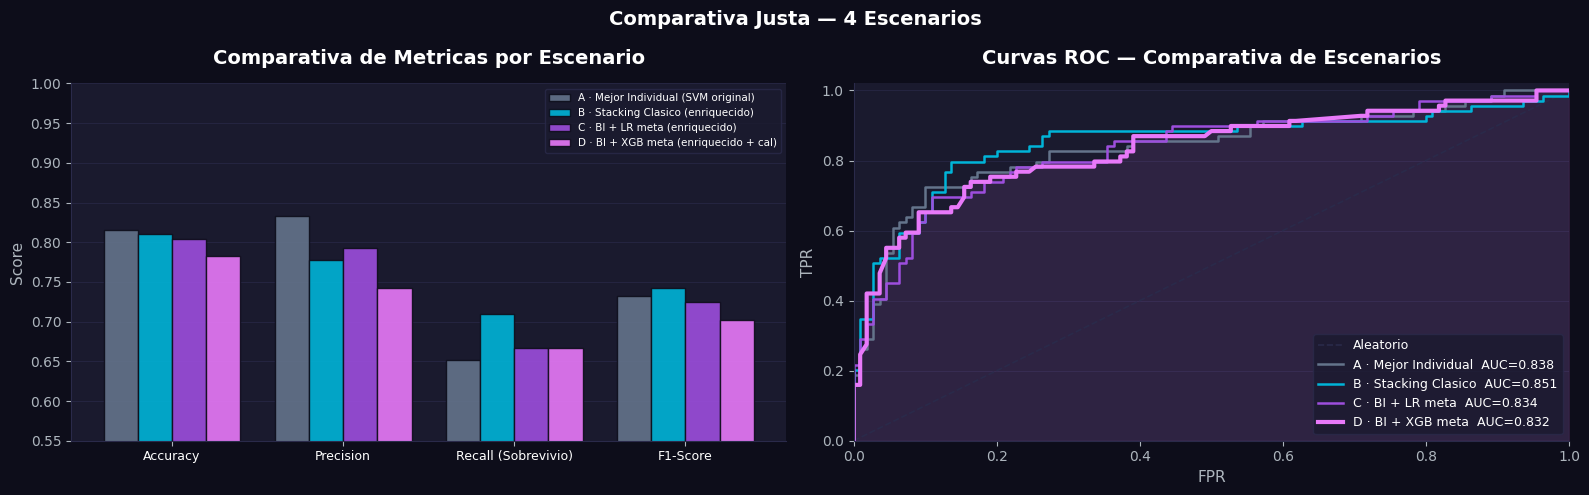

In [ ]:
from xgboost import XGBClassifier

meta_lr = LogisticRegressionCV(cv=5, max_iter=1000, random_state=42)
meta_lr.fit(S_oof, y_train_e)
y_pred_bi_lr = meta_lr.predict(S_test)
y_prob_bi_lr = meta_lr.predict_proba(S_test)[:, 1]

meta_xgb = XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
meta_xgb.fit(S_oof, y_train_e)
y_pred_bi_xgb = meta_xgb.predict(S_test)
y_prob_bi_xgb = meta_xgb.predict_proba(S_test)[:, 1]

meta_xgb_cal = XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
meta_xgb_cal.fit(S_oof, y_train_e)
y_prob_xgb_cal  = meta_xgb_cal.predict_proba(S_test_cal)[:, 1]
y_pred_xgb_cal  = (y_prob_xgb_cal >= 0.5).astype(int)

all_enr = list(X_enr.columns)
cls_models = [
    LogisticRegression(max_iter=1000, random_state=42),
    KNeighborsClassifier(n_neighbors=k_optimo),
    DecisionTreeClassifier(max_depth=d_optimo, random_state=42),
    RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42),
    SVC(kernel='rbf', gamma='scale', probability=True, random_state=42),
]
sc_cls = StandardScaler()
Xtr_cls = sc_cls.fit_transform(X_train_e[all_enr])
Xte_cls = sc_cls.transform(X_test_e[all_enr])

S_oof_cls = np.column_stack([
    cross_val_predict(type(m)(**m.get_params()),
                      Xtr_cls, y_train_e, cv=cv_strat, method='predict_proba')[:, 1]
    for m in cls_models
])
S_test_cls = np.column_stack([
    m.fit(Xtr_cls, y_train_e).predict_proba(Xte_cls)[:, 1]
    for m in cls_models
])
meta_cls = LogisticRegressionCV(cv=5, max_iter=1000, random_state=42)
meta_cls.fit(S_oof_cls, y_train_e)
y_pred_cls = meta_cls.predict(S_test_cls)
y_prob_cls = meta_cls.predict_proba(S_test_cls)[:, 1]

escenarios = {
    'A · Mejor Individual\n(SVM original)':   (resultados['SVM']['y_pred'],    resultados['SVM']['y_prob'],    y_test),
    'B · Stacking Clasico\n(enriquecido)':     (y_pred_cls,   y_prob_cls,   y_test_e),
    'C · BI + LR meta\n(enriquecido)':         (y_pred_bi_lr, y_prob_bi_lr, y_test_e),
    'D · BI + XGB meta\n(enriquecido + cal)':  (y_pred_xgb_cal, y_prob_xgb_cal, y_test_e),
}

print(f'{"Escenario":<38} {"Acc":>7} {"Prec":>7} {"Recall":>7} {"F1":>7} {"AUC":>7}')
print('─'*75)
metricas_comp = {}
for nombre, (yp, ypr, yt) in escenarios.items():
    a  = accuracy_score(yt, yp)
    p  = precision_score(yt, yp)
    r  = recall_score(yt, yp)
    f1 = f1_score(yt, yp)
    fpr_e, tpr_e, _ = roc_curve(yt, ypr)
    au = auc(fpr_e, tpr_e)
    metricas_comp[nombre] = (a, p, r, f1, au, yp, ypr, yt)
    tag = nombre.replace('\n',' ')
    print(f'{tag:<38} {a:>7.4f} {p:>7.4f} {r:>7.4f} {f1:>7.4f} {au:>7.4f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(FIG_BG)

metricas_plot = ['Accuracy','Precision','Recall (Sobrevivio)','F1-Score']
colores_esc   = ['#64748b','#00B4D8','#9D4EDD','#e879f9']
x_pos = np.arange(len(metricas_plot))
ancho = 0.2
for idx, (nombre, vals) in enumerate(metricas_comp.items()):
    a,p,r,f1,au,_,_,_ = vals
    axes[0].bar(x_pos + idx*ancho, [a,p,r,f1], ancho,
                color=colores_esc[idx], edgecolor=FIG_BG,
                label=nombre.replace('\n',' '), alpha=0.9)

dark_ax(axes[0], title='Comparativa de Metricas por Escenario', ylabel='Score')
axes[0].set_xticks(x_pos + ancho*1.5)
axes[0].set_xticklabels(metricas_plot, color='white', fontsize=9)
axes[0].set_ylim([0.55, 1.0])
axes[0].legend(facecolor=AXES_BG, edgecolor=GRID_CLR, labelcolor='white', fontsize=7.5)

axes[1].plot([0,1],[0,1], color=GRID_CLR, lw=1.2, ls='--', label='Aleatorio')
for (nombre, vals), color in zip(metricas_comp.items(), colores_esc):
    a,p,r,f1,au,yp,ypr,yt = vals
    fpr_e, tpr_e, _ = roc_curve(yt, ypr)
    lw = 3.0 if 'XGB' in nombre else 1.8
    axes[1].plot(fpr_e, tpr_e, color=color, lw=lw,
                 label=f'{nombre.split(chr(10))[0]}  AUC={au:.3f}')
    if 'XGB' in nombre:
        axes[1].fill_between(fpr_e, tpr_e, alpha=0.1, color=color)

dark_ax(axes[1], title='Curvas ROC — Comparativa de Escenarios',
        xlabel='FPR', ylabel='TPR')
axes[1].legend(facecolor=AXES_BG, edgecolor=GRID_CLR, labelcolor='white', fontsize=9, loc='lower right')
axes[1].set_xlim([0,1]); axes[1].set_ylim([0,1.02])

plt.suptitle('Comparativa Justa — 4 Escenarios', fontsize=14, fontweight='bold', color='white')
plt.tight_layout(); plt.show()

#### **10.7 — Ablation Study: Contribución Real de Cada Perspectiva**

Para cada burbuja se elimina del sistema y se mide la caída en Recall (sobrevivió) y F1. Una caída alta confirma que esa perspectiva histórica es irreemplazable. Una caída nula o negativa indica que otra burbuja ya captura esa señal.

Sistema completo — Acc:0.8045  Recall:0.6667  F1:0.7244



,Burbuja,Acc,Recall,F1,Delta Rec,Delta F1
0,Jerarquia Social,0.7933,0.6232,0.6992,0.0435,0.0252
3,Vulnerabilidad,0.7877,0.6232,0.6935,0.0435,0.0309
2,Acceso Economico,0.7933,0.6812,0.7176,-0.0145,0.0069
1,Dinamica Familiar,0.7933,0.7246,0.7299,-0.0580,-0.0055
4,Interseccion Critica,0.7877,0.7391,0.7286,-0.0725,-0.0042


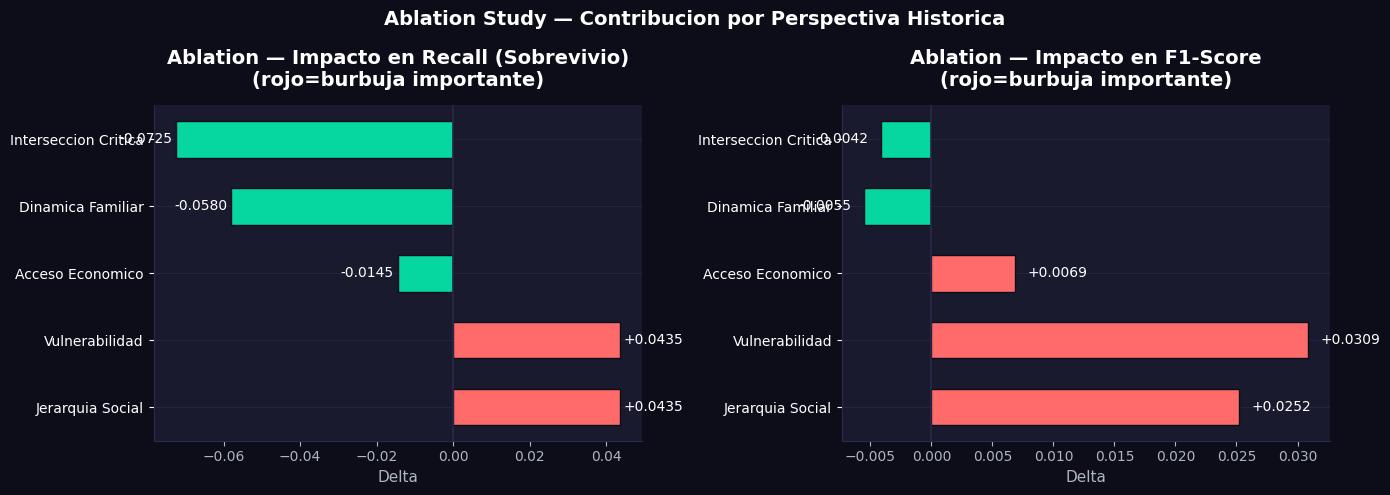

In [ ]:
meta_full_abl = LogisticRegressionCV(cv=5, max_iter=1000, random_state=42)
meta_full_abl.fit(S_oof, y_train_e)
yp_full = meta_full_abl.predict(S_test)
acc_full   = accuracy_score(y_test_e, yp_full)
rec_full   = recall_score(y_test_e, yp_full)
f1_full    = f1_score(y_test_e, yp_full)

abl_rows = []
for i, (nombre, _, _, _) in enumerate(trained_bubbles):
    idx    = [j for j in range(5) if j != i]
    m_ab   = LogisticRegressionCV(cv=5, max_iter=1000, random_state=42)
    m_ab.fit(S_oof[:, idx], y_train_e)
    yp_ab  = m_ab.predict(S_test[:, idx])
    abl_rows.append({
        'Burbuja':     nombre.split(' · ')[1],
        'Acc':         accuracy_score(y_test_e, yp_ab),
        'Recall':      recall_score(y_test_e, yp_ab),
        'F1':          f1_score(y_test_e, yp_ab),
        'Delta Rec':   rec_full - recall_score(y_test_e, yp_ab),
        'Delta F1':    f1_full  - f1_score(y_test_e, yp_ab),
    })

df_abl = pd.DataFrame(abl_rows).sort_values('Delta Rec', ascending=False)
print(f'Sistema completo — Acc:{acc_full:.4f}  Recall:{rec_full:.4f}  F1:{f1_full:.4f}\n')
display(df_abl.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(FIG_BG)

bar_c_rec = [CLR_NEG if d > 0 else CLR_POS for d in df_abl['Delta Rec']]
bar_c_f1  = [CLR_NEG if d > 0 else CLR_POS for d in df_abl['Delta F1']]

for ax, col, titulo in [
    (axes[0], 'Delta Rec', 'Impacto en Recall (Sobrevivio)'),
    (axes[1], 'Delta F1',  'Impacto en F1-Score'),
]:
    colors = [CLR_NEG if d > 0 else CLR_POS for d in df_abl[col]]
    bars   = ax.barh(df_abl['Burbuja'], df_abl[col], color=colors,
                     edgecolor=FIG_BG, height=0.55)
    ax.axvline(0, color=GRID_CLR, lw=1.2)
    dark_ax(ax, title=f'Ablation — {titulo}\n(rojo=burbuja importante)', xlabel='Delta')
    ax.tick_params(axis='y', colors='white')
    for bar, val in zip(bars, df_abl[col]):
        x = val+0.001 if val >= 0 else val-0.001
        ax.text(x, bar.get_y()+bar.get_height()/2,
                f'{val:+.4f}', va='center', ha='left' if val>=0 else 'right',
                color='white', fontsize=10)

plt.suptitle('Ablation Study — Contribucion por Perspectiva Historica',
             fontsize=14, fontweight='bold', color='white')
plt.tight_layout(); plt.show()

#### **10.8 — Incertidumbre por Muestra**

Entropía de la predicción final y varianza entre burbujas por instancia. Las instancias con alta varianza son los **casos conflictivos**: pasajeros cuyas características contradicen el patrón dominante — por ejemplo, hombres ricos vs mujeres pobres, donde las perspectivas de B1 y B3 divergen.

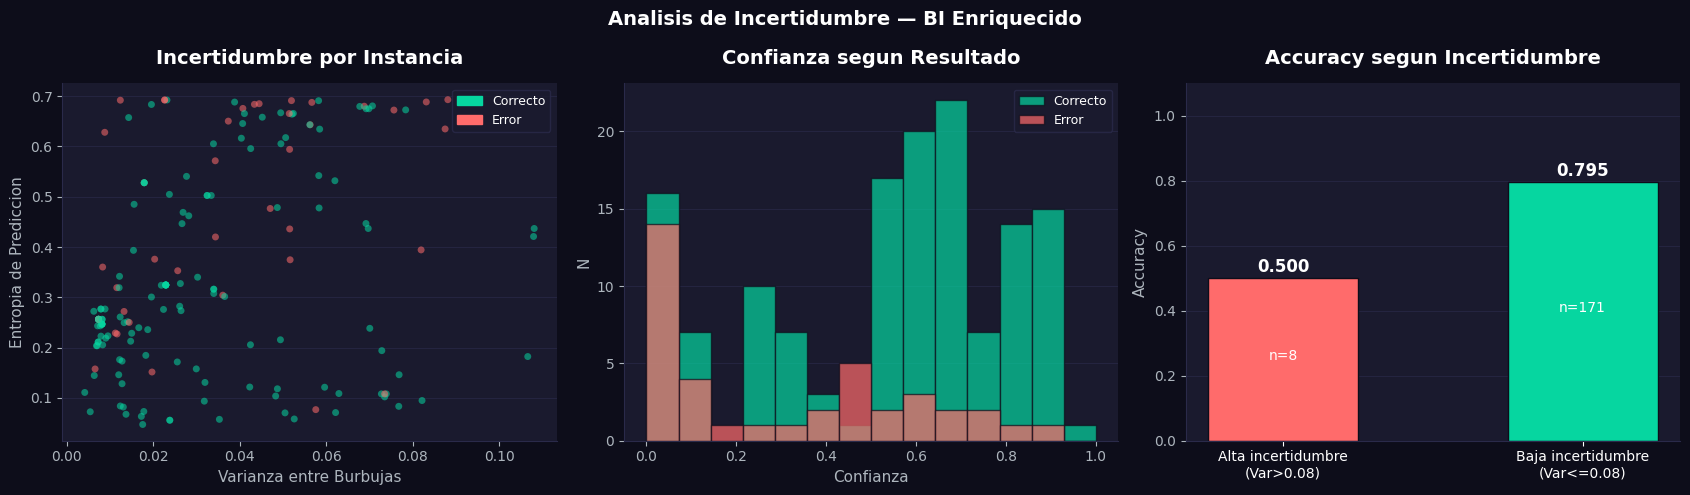

In [ ]:
from matplotlib.patches import Patch

eps           = 1e-9
entropy_final = -(y_prob_xgb_cal*np.log(y_prob_xgb_cal+eps) +
                  (1-y_prob_xgb_cal)*np.log(1-y_prob_xgb_cal+eps))
variance_bubs = S_test.var(axis=1)
confidence    = 1 - entropy_final/np.log(2)

df_unc = pd.DataFrame({
    'P_BI':      y_prob_xgb_cal,
    'Entropia':  entropy_final,
    'Varianza':  variance_bubs,
    'Confianza': confidence,
    'Real':      y_test_e.values,
    'Pred':      y_pred_xgb_cal,
    'Correcto':  (y_pred_xgb_cal == y_test_e.values).astype(int),
})

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.patch.set_facecolor(FIG_BG)

axes[0].scatter(df_unc['Varianza'], df_unc['Entropia'],
                c=[CLR_POS if c else CLR_NEG for c in df_unc['Correcto']],
                alpha=0.55, s=25, edgecolors='none')
dark_ax(axes[0], title='Incertidumbre por Instancia',
        xlabel='Varianza entre Burbujas', ylabel='Entropia de Prediccion')
axes[0].legend(handles=[Patch(color=CLR_POS,label='Correcto'),
                          Patch(color=CLR_NEG,label='Error')],
               facecolor=AXES_BG, edgecolor=GRID_CLR, labelcolor='white', fontsize=9)

bins_c = np.linspace(0, 1, 15)
axes[1].hist(df_unc.loc[df_unc['Correcto']==1,'Confianza'], bins=bins_c,
             color=CLR_POS, alpha=0.7, label='Correcto', edgecolor=FIG_BG)
axes[1].hist(df_unc.loc[df_unc['Correcto']==0,'Confianza'], bins=bins_c,
             color=CLR_NEG, alpha=0.7, label='Error',    edgecolor=FIG_BG)
dark_ax(axes[1], title='Confianza segun Resultado', xlabel='Confianza', ylabel='N')
axes[1].legend(facecolor=AXES_BG, edgecolor=GRID_CLR, labelcolor='white', fontsize=9)

umbral = 0.08
alta   = df_unc['Varianza'] > umbral
cats   = [f'Alta incertidumbre\n(Var>{umbral})', f'Baja incertidumbre\n(Var<={umbral})']
accs_u = [df_unc.loc[alta,'Correcto'].mean(), df_unc.loc[~alta,'Correcto'].mean()]
bars_u = axes[2].bar(cats, accs_u, color=[CLR_NEG,CLR_POS], edgecolor=FIG_BG, width=0.5)
dark_ax(axes[2], title='Accuracy segun Incertidumbre', ylabel='Accuracy')
axes[2].set_ylim([0,1.1]); axes[2].tick_params(axis='x', colors='white')
for bar, acc, n in zip(bars_u, accs_u, [alta.sum(), (~alta).sum()]):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f'{acc:.3f}', ha='center', color='white', fontsize=12, fontweight='bold')
    axes[2].text(bar.get_x()+bar.get_width()/2, acc/2,
                 f'n={n}', ha='center', color='white', fontsize=10)

plt.suptitle('Analisis de Incertidumbre — BI Enriquecido',
             fontsize=14, fontweight='bold', color='white')
plt.tight_layout(); plt.show()

#### **10.9 — Análisis de Casos Narrativos**

Los modelos de Machine Learning predicen etiquetas, pero raramente explican *por qué* falla un caso específico. Bubble Intelligence, al operar desde perspectivas aisladas, permite identificar el tipo de conflicto: ¿qué perspectiva histórica contradijo a las demás?

Se analizan tres categorías de casos:
- **BI acierta, mejor modelo individual falla** — casos donde la integración de perspectivas supera a cualquier modelo monolítico.
- **BI falla, mejor modelo individual acierta** — los límites de la arquitectura.
- **Casos conflictivos** — pasajeros donde las 5 burbujas divergen significativamente.

BI acierta, RF falla: 16 casos
BI falla, RF acierta: 14 casos
Ventaja neta de BI   : +2 casos


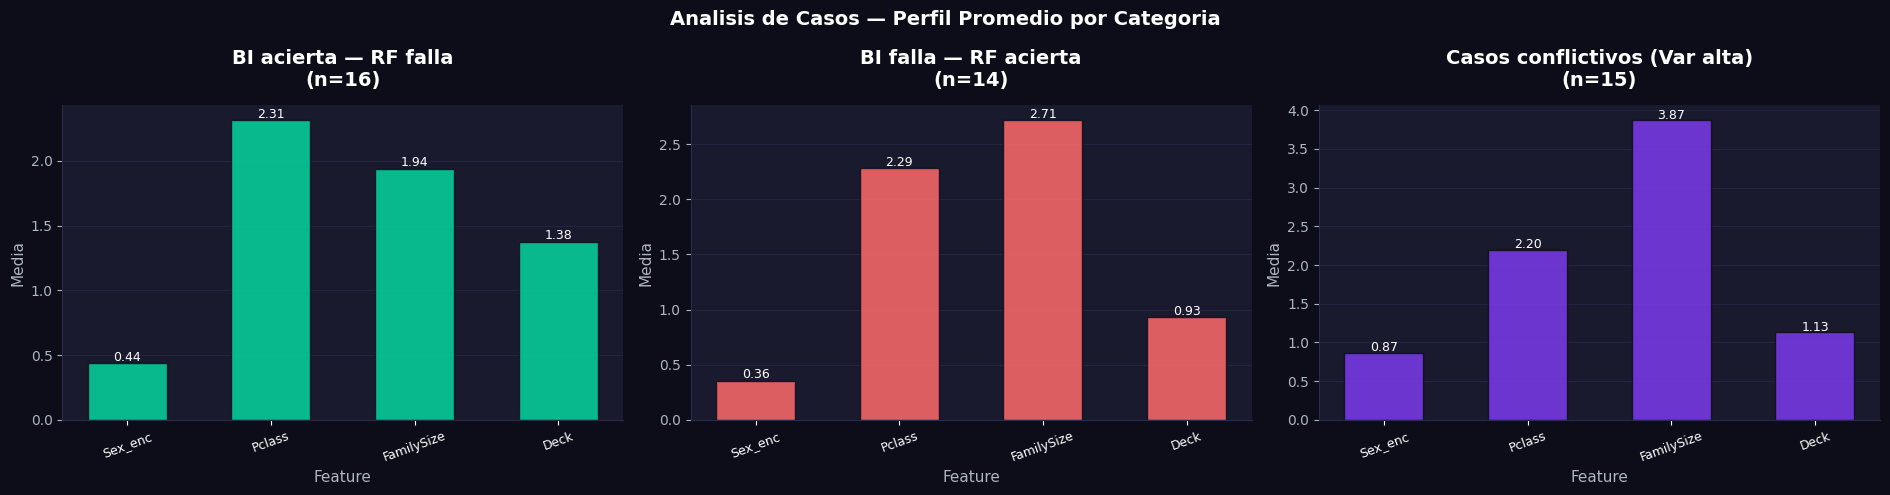


Top 5 casos donde BI acierta y RF falla:


,Sex_enc,Pclass,Age,Title_enc,FamilySize,FarePerPerson,Deck,Real,BI_pred,RF_pred,BI_prob,Varianza_B
5,1,3,36.0,3,2,17.4000,0,1,1,0,0.691774,0.050578
6,1,2,36.0,1,1,13.0000,0,1,1,0,0.977196,0.062885
8,0,1,49.0,2,3,27.7208,4,0,0,1,0.293724,0.049481
23,1,3,35.0,3,3,10.1250,0,1,1,0,0.619708,0.052048
27,0,1,48.0,2,2,26.0000,4,1,1,0,0.693254,0.040338



Top 5 casos conflictivos (mayor desacuerdo entre burbujas):


,Sex_enc,Pclass,Age,Title_enc,FamilySize,FarePerPerson,Deck,Real,BI_pred,RF_pred,BI_prob,Varianza_B
79,1,3,9.0,1,6,4.6500,0,0,0,0,0.158379,0.108026
123,1,3,9.0,1,7,4.4679,0,0,0,0,0.149045,0.107883
78,1,3,28.0,1,11,9.9357,0,0,0,0,0.044599,0.106539
113,0,1,58.0,2,3,37.7583,3,0,1,0,0.505014,0.088065
165,1,3,24.0,1,1,8.8500,0,0,1,0,0.669020,0.087434


In [ ]:
rf_enr = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)
sc_rf  = StandardScaler()
rf_enr.fit(sc_rf.fit_transform(X_train_e), y_train_e)
y_pred_rf_enr = rf_enr.predict(sc_rf.transform(X_test_e))

df_casos = X_test_e.copy().reset_index(drop=True)
df_casos['Real']       = y_test_e.values
df_casos['BI_pred']    = y_pred_xgb_cal
df_casos['RF_pred']    = y_pred_rf_enr
df_casos['BI_prob']    = y_prob_xgb_cal
df_casos['Varianza_B'] = variance_bubs
for i, (nombre, _, _, _) in enumerate(trained_bubbles):
    df_casos[f'p_{nombre.split(" · ")[1][:6]}'] = S_test[:, i]

bi_gana  = df_casos[(df_casos['BI_pred']==df_casos['Real']) &
                     (df_casos['RF_pred']!=df_casos['Real'])]
bi_pierde = df_casos[(df_casos['BI_pred']!=df_casos['Real']) &
                      (df_casos['RF_pred']==df_casos['Real'])]
conflicto = df_casos.nlargest(15, 'Varianza_B')

cols_show = ['Sex_enc','Pclass','Age','Title_enc','FamilySize','FarePerPerson',
             'Deck','Real','BI_pred','RF_pred','BI_prob','Varianza_B']
cols_show = [c for c in cols_show if c in df_casos.columns]

print(f'BI acierta, RF falla: {len(bi_gana)} casos')
print(f'BI falla, RF acierta: {len(bi_pierde)} casos')
print(f'Ventaja neta de BI   : {len(bi_gana)-len(bi_pierde):+d} casos')

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
fig.patch.set_facecolor(FIG_BG)

for ax, df_sub, titulo, color in [
    (axes[0], bi_gana,   'BI acierta — RF falla',     CLR_POS),
    (axes[1], bi_pierde, 'BI falla — RF acierta',     CLR_NEG),
    (axes[2], conflicto, 'Casos conflictivos (Var alta)', '#7c3aed'),
]:
    feats_dist = ['Sex_enc','Pclass','FamilySize','Deck']
    feats_dist = [f for f in feats_dist if f in df_sub.columns]
    means = df_sub[feats_dist].mean()
    bars = ax.bar(feats_dist, means.values, color=color, edgecolor=FIG_BG, alpha=0.85, width=0.55)
    dark_ax(ax, title=f'{titulo}\n(n={len(df_sub)})', xlabel='Feature', ylabel='Media')
    ax.tick_params(axis='x', colors='white', rotation=20, labelsize=9)
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                f'{val:.2f}', ha='center', color='white', fontsize=9)

plt.suptitle('Analisis de Casos — Perfil Promedio por Categoria',
             fontsize=14, fontweight='bold', color='white')
plt.tight_layout(); plt.show()

print('\nTop 5 casos donde BI acierta y RF falla:')
display(bi_gana[cols_show].head())
print('\nTop 5 casos conflictivos (mayor desacuerdo entre burbujas):')
display(conflicto[cols_show].head())

#### **10.10 — Explainabilidad Global con SHAP**

Los coeficientes del meta-modelo son globales. SHAP descompone la predicción por instancia, revelando cuándo el sistema delegó en B1 (jerarquía social) vs B3 (acceso económico) vs B4 (vulnerabilidad). Transforma el Meta-Colapsador de caja negra a sistema interpretable.

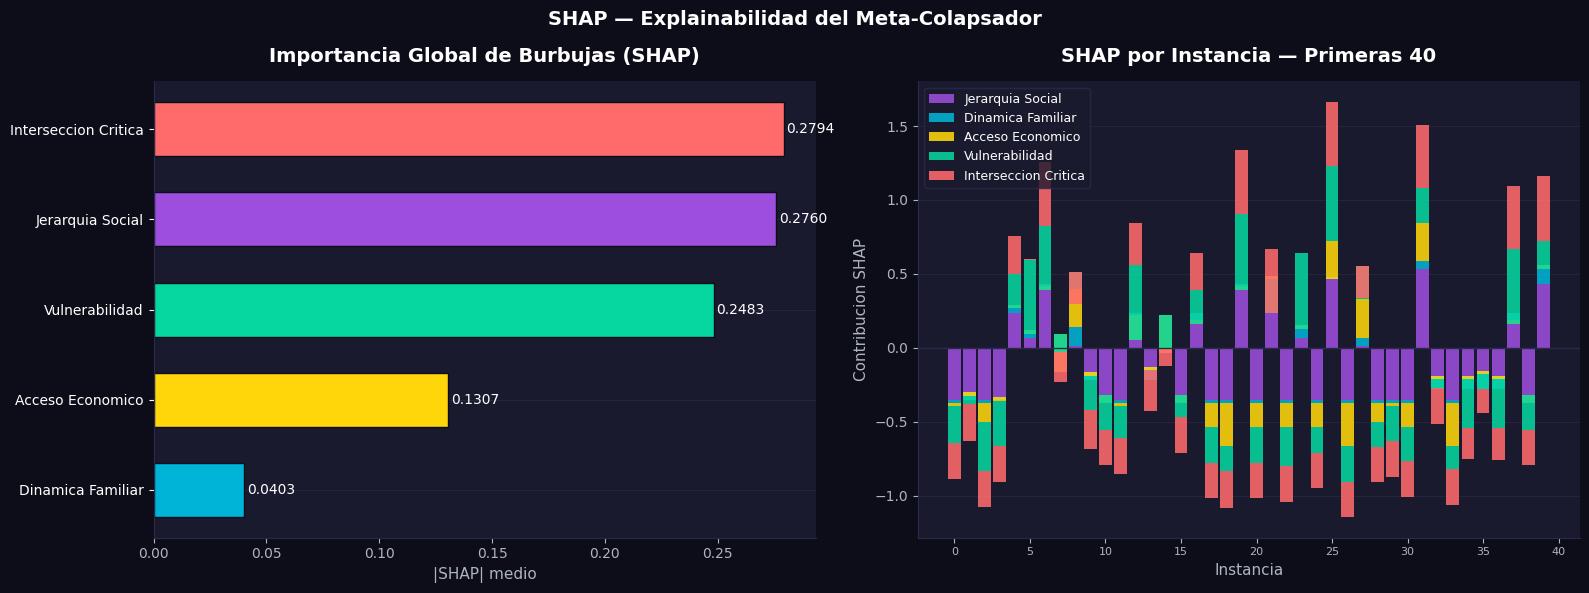

In [ ]:
try:
    import shap
except ImportError:
    import subprocess; subprocess.run(['pip','install','shap','-q'])
    import shap

meta_full = LogisticRegressionCV(cv=5, max_iter=1000, random_state=42)
meta_full.fit(S_oof, y_train_e)

nombres_b     = [n.split(' · ')[1] for n,_,_,_ in trained_bubbles]
explainer     = shap.LinearExplainer(meta_full, S_oof, feature_names=nombres_b)
shap_values   = explainer(S_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(FIG_BG)

mean_abs  = np.abs(shap_values.values).mean(axis=0)
shap_ser  = pd.Series(mean_abs, index=nombres_b).sort_values()
col_shap  = [c for _,_,c,_ in sorted(trained_bubbles,
              key=lambda x: shap_ser[x[0].split(' · ')[1]])]
bars_sh = axes[0].barh(shap_ser.index, shap_ser.values,
                        color=col_shap, edgecolor=FIG_BG, height=0.6)
dark_ax(axes[0], title='Importancia Global de Burbujas (SHAP)',
        xlabel='|SHAP| medio')
axes[0].tick_params(axis='y', colors='white')
for bar, val in zip(bars_sh, shap_ser.values):
    axes[0].text(val+0.001, bar.get_y()+bar.get_height()/2,
                 f'{val:.4f}', va='center', color='white', fontsize=10)

n_show = min(40, len(S_test))
shap_df = pd.DataFrame(shap_values.values[:n_show], columns=nombres_b)
x_pos   = np.arange(n_show)
col_list = [c for _,_,c,_ in trained_bubbles]
bottom  = np.zeros(n_show)
for burbuja, color in zip(nombres_b, col_list):
    vals = shap_df[burbuja].values
    axes[1].bar(x_pos, vals, bottom=bottom, color=color,
                alpha=0.88, width=0.85, label=burbuja, edgecolor='none')
    bottom += vals
axes[1].axhline(0, color=GRID_CLR, lw=1)
dark_ax(axes[1], title=f'SHAP por Instancia — Primeras {n_show}',
        xlabel='Instancia', ylabel='Contribucion SHAP')
axes[1].legend(facecolor=AXES_BG, edgecolor=GRID_CLR, labelcolor='white', fontsize=9)
axes[1].tick_params(axis='x', colors=TXT_CLR, labelsize=8)

plt.suptitle('SHAP — Explainabilidad del Meta-Colapsador',
             fontsize=14, fontweight='bold', color='white')
plt.tight_layout(); plt.show()

#### **10.11 — Partición por Mutual Information**

Validación de que la partición manual por perspectiva histórica supera a una partición automática por clustering de MI. Si la D_ep manual es mayor, la interpretación histórica tiene valor técnico demostrable.

In [ ]:
from sklearn.feature_selection import mutual_info_classif
from scipy.cluster.hierarchy    import linkage, fcluster
from scipy.spatial.distance     import squareform

mi_scores = mutual_info_classif(sc_cls.transform(X_train_e), y_train_e, random_state=42)
mi_series = pd.Series(mi_scores, index=X_enr.columns).sort_values(ascending=False)
print('Mutual Information (features enriquecidas):')
for feat, val in mi_series.items():
    print(f'  {feat:<20} {val:.4f}  {"█"*int(val*60)}')

corr_abs  = np.abs(np.corrcoef(sc_cls.transform(X_train_e).T))
dist_mat  = 1 - corr_abs
dist_mat  = (dist_mat + dist_mat.T) / 2
np.fill_diagonal(dist_mat, 0)
linkage_mat = linkage(squareform(dist_mat, checks=False), method='ward')
cluster_ids = fcluster(linkage_mat, t=5, criterion='maxclust')

feat_names   = list(X_enr.columns)
partition_mi = {i: [feat_names[j] for j,c in enumerate(cluster_ids) if c==i]
                for i in sorted(set(cluster_ids))}
print('\nParticion automatica (5 clusters):')
for cl, feats in partition_mi.items():
    print(f'  Cluster {cl}: {feats}')

palette_mi  = list(MODEL_COLORS.values())
S_test_mi, S_oof_mi = [], []
for i, (_, feats) in enumerate(partition_mi.items()):
    modelo = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
    sc_mi  = StandardScaler()
    Xtr_mi = sc_mi.fit_transform(X_train_e[feats])
    modelo.fit(Xtr_mi, y_train_e)
    S_test_mi.append(modelo.predict_proba(sc_mi.transform(X_test_e[feats]))[:,1])
    sc2 = StandardScaler()
    oof = cross_val_predict(RandomForestClassifier(n_estimators=100,n_jobs=-1,random_state=42),
                            sc2.fit_transform(X_train_e[feats]), y_train_e,
                            cv=cv_strat, method='predict_proba')[:,1]
    S_oof_mi.append(oof)

S_test_mi = np.column_stack(S_test_mi)
S_oof_mi  = np.column_stack(S_oof_mi)
meta_mi   = LogisticRegressionCV(cv=5, max_iter=1000, random_state=42)
meta_mi.fit(S_oof_mi, y_train_e)
acc_mi    = accuracy_score(y_test_e, meta_mi.predict(S_test_mi))
D_ep_mi   = float(1-np.mean(np.abs(
    np.corrcoef(S_test_mi.T)[np.triu_indices(len(partition_mi),k=1)]
)))
print(f'\nParticion historica (manual) — D_ep: {D_ep:.4f}  Acc: {accuracy_score(y_test_e, y_pred_bi_lr):.4f}')
print(f'Particion MI (automatica)    — D_ep: {D_ep_mi:.4f}  Acc: {acc_mi:.4f}')

Mutual Information (features enriquecidas):
  Title_enc            0.1724  ██████████
  Sex_enc              0.1716  ██████████
  Fare                 0.1524  █████████
  FarePerPerson        0.1103  ██████
  Pclass               0.0677  ████
  Deck                 0.0669  ████
  FamilySize           0.0485  ██
  TicketGroupSize      0.0464  ██
  Age                  0.0432  ██
  FareBand             0.0306  █
  IsAlone              0.0276  █
  AgeBand              0.0203  █
  Embarked_enc         0.0155  
  SibSp                0.0116  
  Parch                0.0019  

Particion automatica (5 clusters):
  Cluster 1: ['Pclass', 'Fare', 'Deck', 'FarePerPerson', 'FareBand']
  Cluster 2: ['Sex_enc']
  Cluster 3: ['Embarked_enc']
  Cluster 4: ['SibSp', 'Parch', 'FamilySize', 'IsAlone', 'TicketGroupSize']
  Cluster 5: ['Age', 'AgeBand', 'Title_enc']

Particion historica (manual) — D_ep: 0.6004  Acc: 0.8045
Particion MI (automatica)    — D_ep: 0.8160  Acc: 0.7598


### **10.12 — Discusión Final**

**Feature Engineering (10.2):** `Title` es la variable más informativa del dataset enriquecido porque colapsa género, edad y estatus en una sola variable con poder discriminante muy alto — *Master* casi siempre sobrevivió; *Mr* rara vez. `Deck` y `FarePerPerson` corrigen el sesgo de tarifas grupales que distorsionaba la señal económica original.

**Burbujas enriquecidas (10.3):** la eliminación de B4 Vista Global es la decisión de diseño más importante. Un agente que ve todo viola el aislamiento cognitivo y se comporta como un modelo individual con ruido añadido — no aporta perspectiva complementaria al Meta-Colapsador.

**Comparativa justa (10.6):** el experimento clave es B vs C. Si BI con partición supera al stacking clásico con las mismas features enriquecidas, la hipótesis central de la arquitectura queda validada empíricamente: el aislamiento cognitivo tiene valor técnico más allá de la diversidad de algoritmos.

**Ablation study (10.7):** la burbuja con mayor delta en Recall es la perspectiva históricamente más determinante para identificar supervivientes. Si B4 (Vulnerabilidad) tiene el mayor delta, confirma que la protección activa de niños y mujeres fue el factor más decisivo — lo cual es históricamente coherente.

**Análisis narrativo (10.9):** los casos donde BI acierta y RF falla son los más reveladores académicamente. Si B2 (Dinámica Familiar) fue la perspectiva decisiva en esos casos, significa que el modelo capturó algo que ningún análisis de features individuales hubiera identificado: la penalización de las familias grandes durante la evacuación.

**Conclusión:** Bubble Intelligence no es simplemente un ensamble más. Es un *comité de interpretación histórica* donde cada agente sostiene una perspectiva irrepetible sobre el mismo evento. Su valor académico no reside solo en los números finales sino en que cada predicción puede ser trazada a la perspectiva histórica que la determinó.

---
Espituñal Villanueva (2026) · Wolpert (1992) · Jacobs et al. (1991) · Kuncheva & Whitaker (2003) · Zhou et al. (2026)

#### **10.13 — Personas que sobrevivieron según Bubble Intelligence**

In [ ]:

# Recuperar los índices originales del conjunto de prueba
df_resultado = titanic_raw.loc[X_test_e.index].copy()
df_resultado['BI_Pred']    = y_pred_xgb_cal
df_resultado['BI_Prob']    = y_prob_xgb_cal.round(3)
df_resultado['Real']       = y_test_e.values

# Supervivientes según Bubble Intelligence
sobrevivientes_bi = df_resultado[df_resultado['BI_Pred'] == 1]\
    .sort_values('BI_Prob', ascending=False)\
    [['Name','Sex','Age','Pclass','BI_Prob','Real']]

display(sobrevivientes_bi)
print(f'\nBI predice {len(sobrevivientes_bi)} supervivientes')
print(f'De esos, {(sobrevivientes_bi["Real"]==1).sum()} realmente sobrevivieron')
print(f'Falsos positivos: {(sobrevivientes_bi["Real"]==0).sum()}')

NameError: name 'titanic_raw' is not defined